# Weather to Gas Coupling: Building the GARCH-X

This notebook builds the exogenous positive cold-anomaly regressor, establishes the empirical facts (fat tails, February timing peak, storage-regime amplification) that motivate the specification, and selects the GARCH-X ladder culminating in E2. The companion notebook 2_ML_Coupling then asks whether a better temperature forecast (OU or ML) makes that surprise more informative than naive climatology.

In this part we look for the GARCH model(s) that we will test on our data. We want to bring out the link between gas volatility and temperature anomalies. However, we do not know how the two are related. Does timing matter (early winter, is the sensitivity of volatility stronger?), is the relationship linear? Finally, is the effect of these anomalies marginal compared to other effects?

Let `Baseline` denote our base GARCH model, defined as:
$$\sigma_{t}^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$$

Let us see whether we can improve this model by adding exogenous variables.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

## Modelling a temperature anomaly

A day with HDD > 0 does not mean that volatility will change drastically. Market participants already price in the normal seasonal drops in temperature. What we care about are the **HDD anomalies**, the days significantly colder than the historical normal for that time of year.

We define the positive HDD anomaly at day $t$ as:

$$\widetilde{HDD}_t^+ = \max\!\left(HDD_t - \bar{HDD}(m_t, d_t),\ 0\right)$$

where:
- $m_t$ is the month and $d_t$ the calendar day
- $\bar{HDD}(m_t, d_t)$ is the historical mean HDD for that same day over the reference period 2000 to 2019

We keep only positive anomalies (winters colder than normal), because these are the ones that create an unanticipated strain on gas demand.

Let us store everything in a unified dataframe with all the HDD anomalies, the realized volatility and the other required variables.

In [102]:
df_chicago = pd.read_csv("../data/processed/chicago_ohare_theta.csv")
df_boston = pd.read_csv("../data/processed/boston_logan_theta.csv")
df_new_york = pd.read_csv("../data/processed/new_york_jfk_theta.csv")
df_minneapolis = pd.read_csv("../data/processed/minneapolis_stpaul_theta.csv")

df_cities = {
    "Chicago O'Hare": df_chicago,
    "Boston Logan": df_boston,
    "New York JFK": df_new_york,
    "Minneapolis St-Paul": df_minneapolis
}

In [103]:
df_natgas = pd.read_csv('../data/Henry_Hub_Natural_Gas_Spot_Price.csv')
df_natgas.columns = df_natgas.columns.str.strip()
df_natgas = df_natgas.rename(columns={
    df_natgas.columns[0]: 'date',
    df_natgas.columns[1]: 'price'
})
df_natgas['date']  = pd.to_datetime(df_natgas['date'], infer_datetime_format=True)
df_natgas['price'] = pd.to_numeric(df_natgas['price'], errors='coerce')
df_natgas = df_natgas.dropna().sort_values('date').set_index('date')
df_natgas['log_ret'] = np.log(df_natgas['price'] / df_natgas['price'].shift(1))
df_natgas['RV21']    = df_natgas['log_ret'].rolling(21).apply(
    lambda x: np.sqrt(252 / 21 * np.sum(x**2)), raw=True
)


In [104]:
def get_hdd_anom(df_city):
    dc = df_city.copy()
    dc['DATE'] = pd.to_datetime(dc['DATE'])
    dc = dc.sort_values('DATE').set_index('DATE')
    dc['month'] = dc.index.month
    dc['day']   = dc.index.day
    ref = dc.loc['2000':'2019']
    seasonal = ref.groupby(['month', 'day'])['HDD'].mean().rename('HDD_normal')
    dc = dc.join(seasonal, on=['month', 'day'])
    dc['HDD_anom_pos'] = (dc['HDD'] - dc['HDD_normal']).clip(lower=0)
    return dc[['HDD', 'HDD_anom_pos']]

chicago_hdd     = get_hdd_anom(df_chicago)
boston_hdd      = get_hdd_anom(df_boston)
new_york_hdd    = get_hdd_anom(df_new_york)
minneapolis_hdd = get_hdd_anom(df_minneapolis)

df_main = pd.DataFrame({
    'price'                  : df_natgas['price'],
    'log_ret'                : df_natgas['log_ret'],
    'RV21'                   : df_natgas['RV21'],
    # Raw HDD per city
    'HDD_chicago'            : chicago_hdd['HDD'],
    'HDD_boston'             : boston_hdd['HDD'],
    'HDD_new_york'           : new_york_hdd['HDD'],
    'HDD_minneapolis'        : minneapolis_hdd['HDD'],
    # HDD⁺ anomaly per city
    'HDD_anom_chicago'       : chicago_hdd['HDD_anom_pos'],
    'HDD_anom_boston'        : boston_hdd['HDD_anom_pos'],
    'HDD_anom_new_york'      : new_york_hdd['HDD_anom_pos'],
    'HDD_anom_minneapolis'   : minneapolis_hdd['HDD_anom_pos'],
})

df_main['month']     = df_main.index.month
df_main['year']      = df_main.index.year
df_main['is_winter'] = df_main['month'].isin([11, 12, 1, 2, 3])

anom_cols = ['HDD_anom_chicago','HDD_anom_boston','HDD_anom_new_york','HDD_anom_minneapolis']
df_main = df_main.dropna(subset=['log_ret', 'RV21'] + anom_cols)

In [105]:
df_main.head()

,price,log_ret,RV21,HDD_chicago,HDD_boston,HDD_new_york,HDD_minneapolis,HDD_anom_chicago,HDD_anom_boston,HDD_anom_new_york,HDD_anom_minneapolis,month,year,is_winter
1997-02-06,2.51,-0.054277,1.346835,21.3333,14.3888,14.3888,21.8889,0.000000,0.0,0.00000,0.000000,2,1997,True
1997-02-07,2.39,-0.048989,1.345806,21.6112,17.7222,15.2222,23.0000,0.500090,0.0,0.00000,0.000000,2,1997,True
1997-02-10,2.42,0.012474,1.315908,20.7778,17.7222,18.8334,24.3888,0.000000,0.0,1.86117,0.000000,2,1997,True
1997-02-11,2.34,-0.033617,1.319196,22.7222,19.1111,17.1667,29.3888,0.000000,0.0,0.00000,3.069350,2,1997,True
1997-02-12,2.42,0.033617,1.324298,24.6666,18.8333,17.1666,32.1666,2.499925,0.0,0.00000,6.166605,2,1997,True


To build an aggregate temperature variable representative of gas demand over our study area, we define a weighted composite HDD:

$$
\widetilde{HDD}_{t}^{+,\text{agg}} = \sum_{c \in \mathcal{C}} w_c \cdot \widetilde{HDD}_{t,c}^+
$$

where $\mathcal{C} = \{\text{Chicago, Boston, New York, Minneapolis}\}$ and $w_c$ is the weight associated with city $c$.

For the choice of weights, two approaches are possible:

- Weighting by the population of the cities
- Weighting by residential natural-gas consumption

We keep the second option. Population is an imperfect proxy. A comparably sized city in Florida structurally consumes less heating gas than a Midwest city. Residential consumption directly captures the intensity of temperature-sensitive gas demand, which is precisely the transmission channel to Henry Hub that we are trying to model.

The annual residential consumption data by state come from the EIA (https://www.eia.gov/dnav/ng/ng_cons_sum_a_EPG0_vrs_mmcf_a.htm)

Each city is represented by its state (Illinois, Massachusetts, New York, Minnesota). The weights are computed as each state's share in the total consumption of the 4 states, **averaged over the common observation period** in order to smooth annual variations and obtain stable weights:

$$
w_c = \frac{\bar{Q}_c}{\sum_{c' \in \mathcal{C}} \bar{Q}_{c'}}
\quad \text{where} \quad 
\bar{Q}_c = \frac{1}{T}\sum_{t=1}^{T} Q_{c,t}
$$

with $Q_{c,t}$ the residential gas consumption of state $c$ in year $t$.

In [106]:
df_eia = pd.read_excel(
    '../data/NG_consumption.xls',
    sheet_name=1,
    header=2
)

In [107]:
df_eia['Date'] = pd.to_datetime(df_eia['Date'], errors='coerce')
df_eia = df_eia.dropna(subset=['Date']).set_index('Date')
df_eia.index = df_eia.index.year  # keep the year only

# Columns of the 4 states
col_illinois     = 'Illinois Natural Gas Residential Consumption (MMcf)'
col_massachusetts = 'Massachusetts Natural Gas Residential Consumption (MMcf)'
col_new_york     = 'New York Natural Gas Residential Consumption (MMcf)'
col_minnesota    = 'Minnesota Natural Gas Residential Consumption (MMcf)'

state_cols = {
    'chicago'     : col_illinois,
   'boston'      : col_massachusetts,
    'new_york'    : col_new_york,
    'minneapolis' : col_minnesota
}

df_states = df_eia[[col_illinois, 
                    col_massachusetts,
                     col_new_york, 
                     col_minnesota]].loc[2000:2024]

print(f"\nPeriod : {df_states.index.min()} to {df_states.index.max()}")
print(f"\nMean per state (MMcf) :")
print(df_states.mean().round(0))

mean_conso = df_states.mean()
total      = mean_conso.sum()
weights    = {city: mean_conso[col] / total 
              for city, col in state_cols.items()}

print(f"\nFinal weights :")
for city, w in weights.items():
    print(f"  {city:15s} : {w:.4f} ({w*100:.1f}%)")


Période : 2000 → 2024

Moyenne par état (MMcf) :
Illinois Natural Gas Residential Consumption (MMcf)         421220.0
Massachusetts Natural Gas Residential Consumption (MMcf)    120320.0
New York Natural Gas Residential Consumption (MMcf)         413254.0
Minnesota Natural Gas Residential Consumption (MMcf)        130318.0
dtype: float64

Poids finaux :
  chicago         : 0.3882 (38.8%)
  boston          : 0.1109 (11.1%)
  new_york        : 0.3808 (38.1%)
  minneapolis     : 0.1201 (12.0%)


In [108]:
df_main['HDD_weighted'] = sum(
    weights[city] * df_main[f'HDD_{city}']
    for city in weights.keys()
)

df_main['HDD_anom_weighted'] = sum(
    weights[city] * df_main[f'HDD_anom_{city}']
    for city in weights.keys()
)

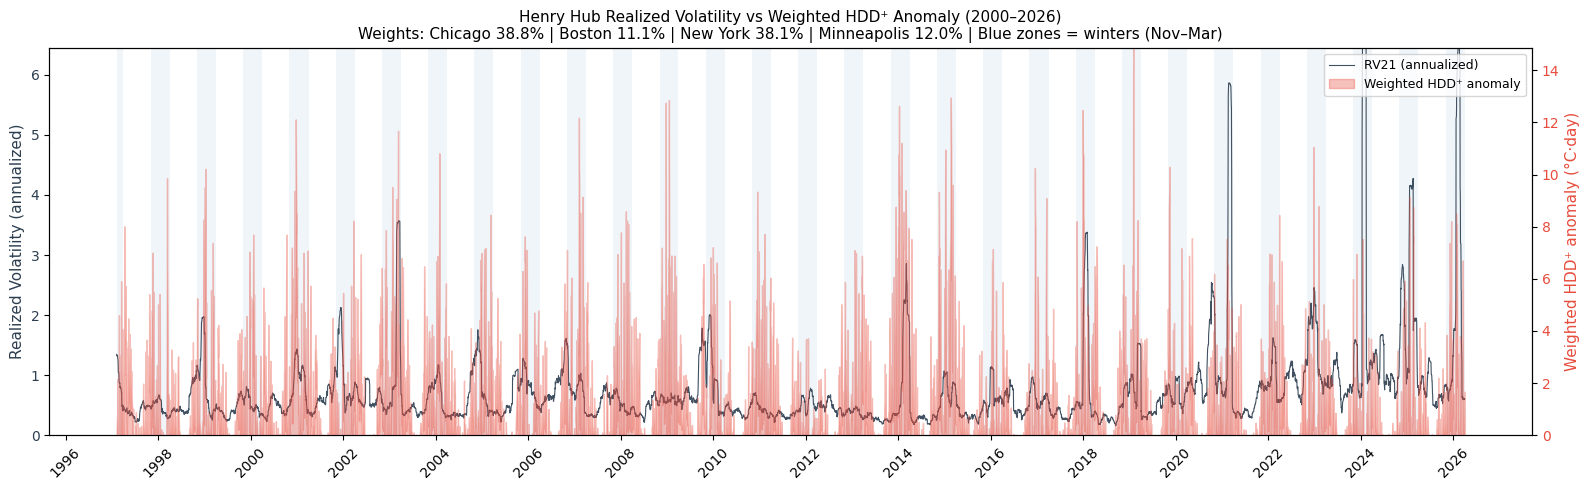

In [109]:
# -----------------------------------------------------------
# RV21 vs Weighted HDD anomaly - dual axis time series
# -----------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(16, 5))

# Highlight winters
winter_mask = df_main['is_winter']
in_winter   = False
start       = None
for date, val in winter_mask.items():
    if val and not in_winter:
        start     = date
        in_winter = True
    elif not val and in_winter:
        ax1.axvspan(start, date, alpha=0.08, color='steelblue', lw=0)
        in_winter = False
if in_winter:
    ax1.axvspan(start, df_main.index[-1], alpha=0.08, color='steelblue', lw=0)

# RV21
ax1.plot(df_main.index, df_main['RV21'], color='#2c3e50',
         lw=0.8, alpha=0.9, label='RV21 (annualized)')
ax1.set_ylabel('Realized Volatility (annualized)', color='#2c3e50', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.set_ylim(0, df_main['RV21'].quantile(0.995) * 1.1)

# Weighted HDD anomaly
ax2 = ax1.twinx()
ax2.fill_between(df_main.index, df_main['HDD_anom_weighted'],
                 alpha=0.35, color='#e74c3c', label='Weighted HDD⁺ anomaly')
ax2.set_ylabel('Weighted HDD⁺ anomaly (°C·day)', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, df_main['HDD_anom_weighted'].quantile(0.999) * 1.2)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

ax1.set_title(
    'Henry Hub Realized Volatility vs Weighted HDD⁺ Anomaly (2000 to 2026)\n'
    f'Weights: Chicago {weights["chicago"]*100:.1f}% | '
    f'Boston {weights["boston"]*100:.1f}% | '
    f'New York {weights["new_york"]*100:.1f}% | '
    f'Minneapolis {weights["minneapolis"]*100:.1f}% '
    '| Blue zones = winters (Nov to Mar)',
    fontsize=11
)
plt.tight_layout()
plt.show()

Several observations stand out from this chart:

The RV21 spikes are almost exclusively wintertime, which confirms that temperature-driven demand shocks are a determining factor of natural-gas volatility.

Some winters with high HDD anomalies do not produce a volatility spike (2011, 2013), others do (2014, 2021). The HDD effect is conditional on other factors, such as the level of storage or the date of the HDD.

In [110]:
df_main.head()

,price,log_ret,RV21,HDD_chicago,HDD_boston,HDD_new_york,HDD_minneapolis,HDD_anom_chicago,HDD_anom_boston,HDD_anom_new_york,HDD_anom_minneapolis,month,year,is_winter,HDD_weighted,HDD_anom_weighted
1997-02-06,2.51,-0.054277,1.346835,21.3333,14.3888,14.3888,21.8889,0.000000,0.0,0.00000,0.000000,2,1997,True,17.985258,0.000000
1997-02-07,2.39,-0.048989,1.345806,21.6112,17.7222,15.2222,23.0000,0.500090,0.0,0.00000,0.000000,2,1997,True,18.913580,0.194125
1997-02-10,2.42,0.012474,1.315908,20.7778,17.7222,18.8334,24.3888,0.000000,0.0,1.86117,0.000000,2,1997,True,20.132151,0.708809
1997-02-11,2.34,-0.033617,1.319196,22.7222,19.1111,17.1667,29.3888,0.000000,0.0,0.00000,3.069350,2,1997,True,21.006670,0.368618
1997-02-12,2.42,0.033617,1.324298,24.6666,18.8333,17.1666,32.1666,2.499925,0.0,0.00000,6.166605,2,1997,True,22.064212,1.711011


In [111]:
df_main["HDD_anom_boston"].describe()

count    7318.000000
mean        1.087921
std         2.034591
min         0.000000
25%         0.000000
50%         0.000000
75%         1.455504
max        15.180490
Name: HDD_anom_boston, dtype: float64

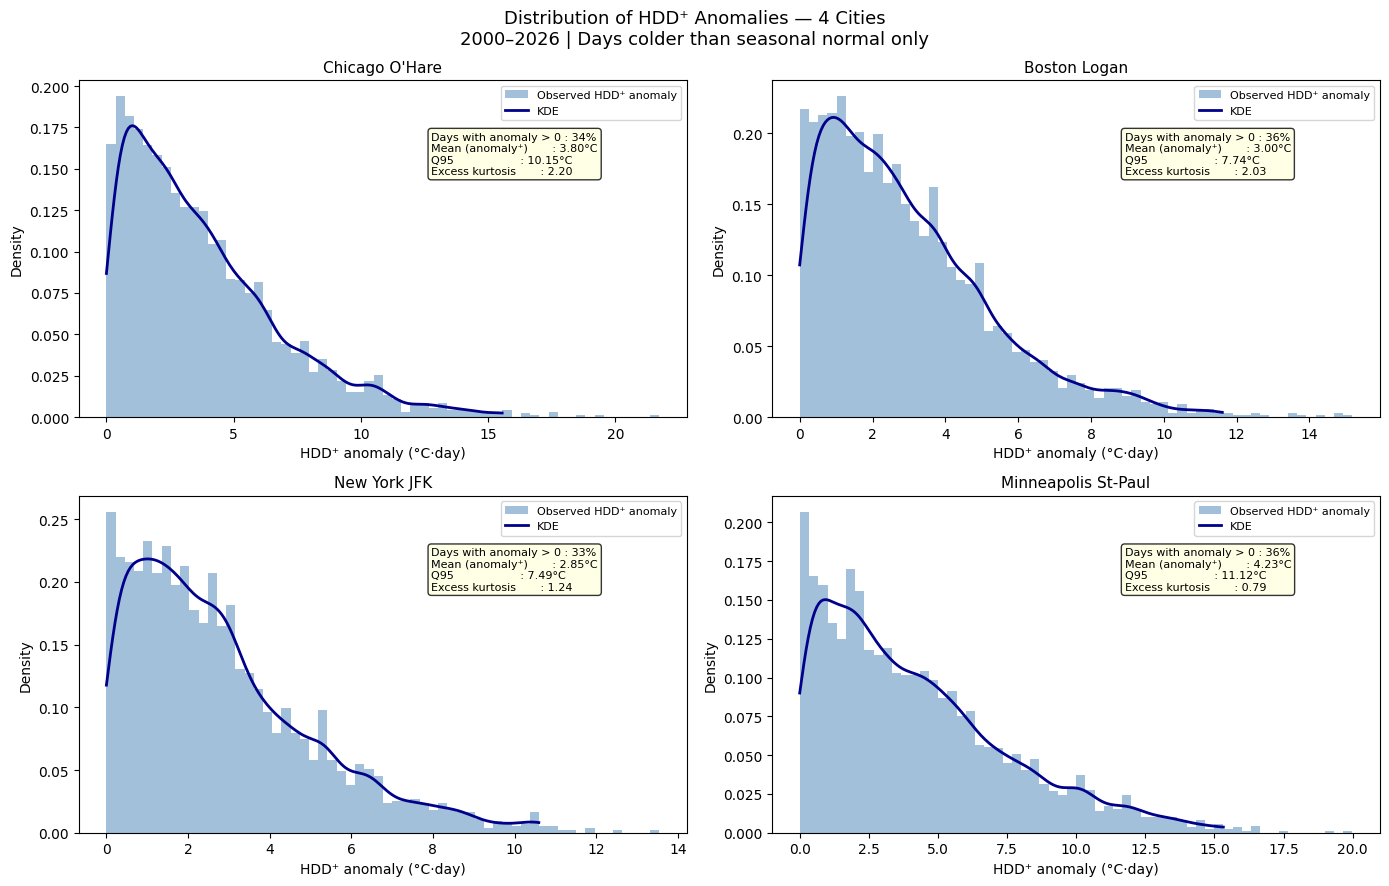

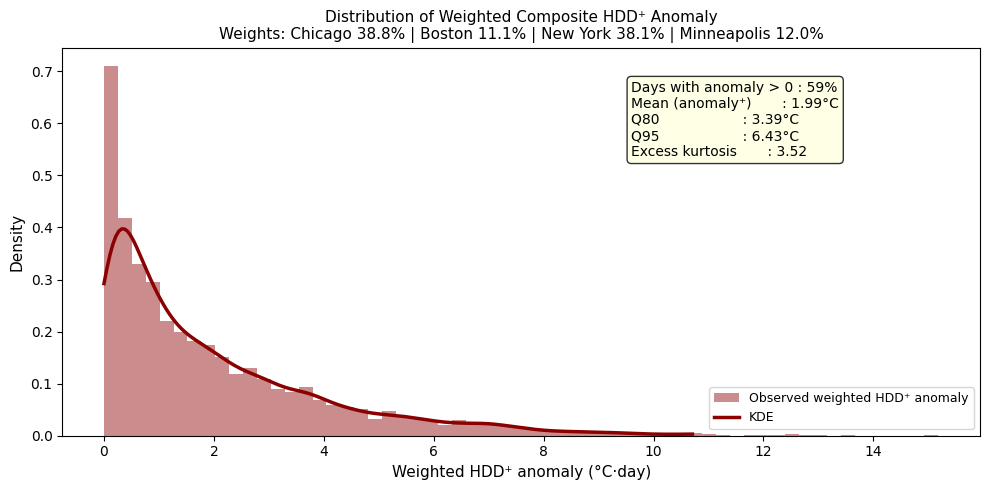

In [112]:
# -----------------------------------------------------------
# Distribution of HDD anomalies - 4 cities
# -----------------------------------------------------------

from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

anom_cols = {
    "Chicago O'Hare"     : 'HDD_anom_chicago',
    'Boston Logan'       : 'HDD_anom_boston',
    'New York JFK'       : 'HDD_anom_new_york',
    'Minneapolis St-Paul': 'HDD_anom_minneapolis',
}

for ax, (city_name, col) in zip(axes.flatten(), anom_cols.items()):

    data     = df_main[col].dropna()
    data_pos = data[data > 0]

    ax.hist(data_pos, bins=60, density=True, color='steelblue',
            alpha=0.5, label='Observed HDD⁺ anomaly')

    kde     = gaussian_kde(data_pos, bw_method=0.15)
    x_range = np.linspace(0, data_pos.quantile(0.995), 200)
    ax.plot(x_range, kde(x_range), color='darkblue', lw=2, label='KDE')

    pct_pos  = (data > 0).mean() * 100
    mean_pos = data_pos.mean()
    p95      = data_pos.quantile(0.95)
    kurt     = data_pos.kurt()

    ax.text(0.58, 0.72,
            f'Days with anomaly > 0 : {pct_pos:.0f}%\n'
            f'Mean (anomaly⁺)       : {mean_pos:.2f}°C\n'
            f'Q95                   : {p95:.2f}°C\n'
            f'Excess kurtosis       : {kurt:.2f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax.set_xlabel('HDD⁺ anomaly (°C·day)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(city_name, fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle('Distribution of HDD⁺ Anomalies - 4 Cities\n'
             '2000 to 2026 | Days colder than seasonal normal only',
             fontsize=13)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Distribution of weighted composite HDD anomaly
# -----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

data     = df_main['HDD_anom_weighted'].dropna()
data_pos = data[data > 0]

ax.hist(data_pos, bins=60, density=True, color='darkred',
        alpha=0.45, label='Observed weighted HDD⁺ anomaly')

kde     = gaussian_kde(data_pos, bw_method=0.15)
x_range = np.linspace(0, data_pos.quantile(0.995), 200)
ax.plot(x_range, kde(x_range), color='darkred', lw=2.5, label='KDE')

pct_pos  = (data > 0).mean() * 100
mean_pos = data_pos.mean()
p80      = data_pos.quantile(0.80)
p95      = data_pos.quantile(0.95)
kurt     = data_pos.kurt()

ax.text(0.62, 0.72,
        f'Days with anomaly > 0 : {pct_pos:.0f}%\n'
        f'Mean (anomaly⁺)       : {mean_pos:.2f}°C\n'
        f'Q80                   : {p80:.2f}°C\n'
        f'Q95                   : {p95:.2f}°C\n'
        f'Excess kurtosis       : {kurt:.2f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('Weighted HDD⁺ anomaly (°C·day)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of Weighted Composite HDD⁺ Anomaly\n'
             f'Weights: Chicago {weights["chicago"]*100:.1f}% | '
             f'Boston {weights["boston"]*100:.1f}% | '
             f'New York {weights["new_york"]*100:.1f}% | '
             f'Minneapolis {weights["minneapolis"]*100:.1f}%',
             fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In each of the histograms we notice fairly heavy distribution tails, suggesting that extreme values are more frequent than in a normal distribution. Let us try to study this in more detail.

## Fat Tail Investigation

To study the behaviour of extreme values (fat tails, the very high HDD anomalies), we can use a quantile regression for high quantiles, from 0.70 to 0.99.

Quantile regression generalizes OLS regression by estimating, instead of the conditional mean of $Y$ given $X$, its **conditional quantile** $Q_\tau[Y|X]$ for any $\tau \in (0,1)$:

$$Q_\tau[RV_t \mid HDD_t] = \alpha_\tau + \gamma_\tau \cdot \widetilde{HDD}_t^{+,\text{agg}}$$

The coefficient $\gamma_\tau$ is estimated by minimizing an asymmetric loss function:

$$\hat{\gamma}_\tau = \arg\min_{\gamma} \sum_{t} \rho_\tau\!\left(RV_t - \alpha - \gamma \cdot \widetilde{HDD}_t^{+,\text{agg}}\right)$$

where $\rho_\tau(u) = u\cdot(\tau - \mathbf{1}_{u < 0})$ penalizes positive and negative residuals asymmetrically according to $\tau$.

Here we want to see whether the effect is **concentrated in the tails**, which would make sense: what is hard to forecast is not a mild anomaly but an intense winter.

Observations : 579
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) 

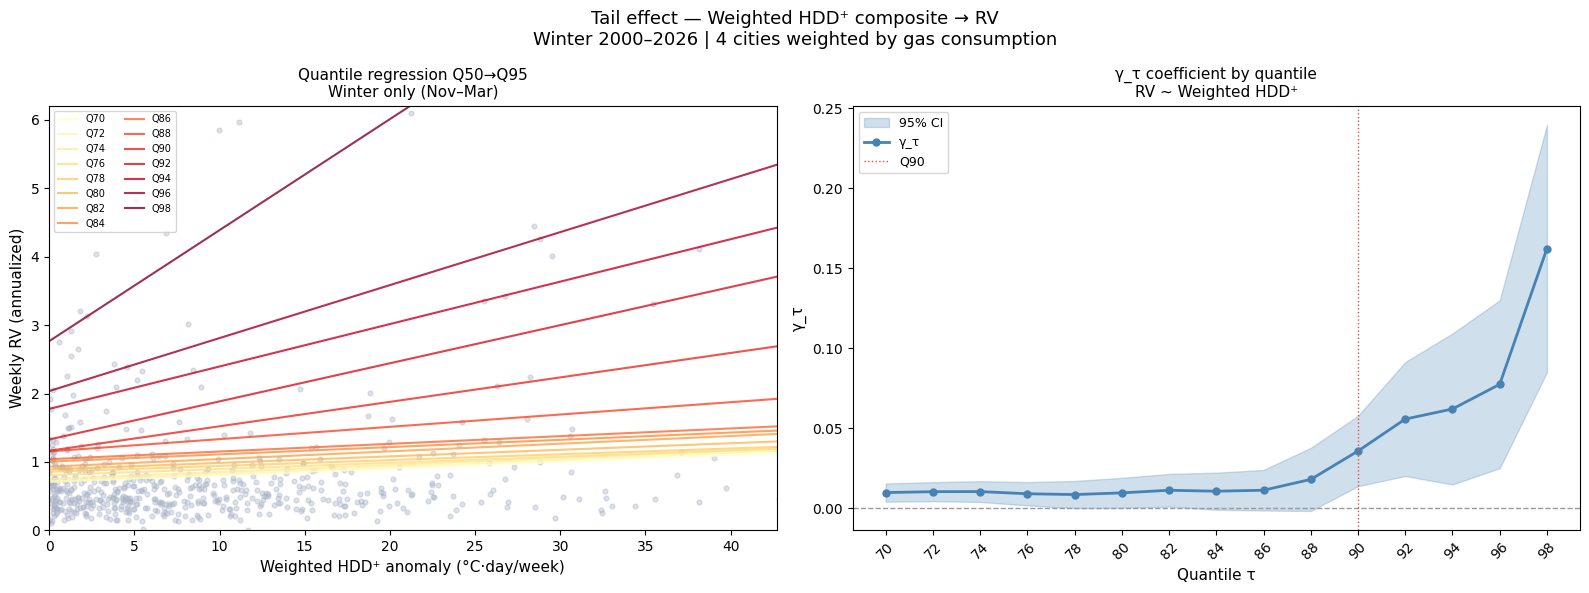

In [113]:
import statsmodels.formula.api as smf
import matplotlib.cm as cm

quantiles = np.arange(0.70, 0.98, 0.02)

cmap = cm.get_cmap('YlOrRd', len(quantiles))

# Weekly dataset with weighted aggregate HDD, no lag
rv_weekly    = df_main['log_ret'].resample('W').apply(
    lambda x: np.sqrt(252) * x.std() if len(x) >= 3 else np.nan
)
hdd_w_weekly = df_main['HDD_anom_weighted'].resample('W').sum()

df_weekly_agg = pd.DataFrame({
    'RV'      : rv_weekly,
    'HDD_anom': hdd_w_weekly,
}).dropna()

df_weekly_agg['month']     = df_weekly_agg.index.month
df_weekly_agg['is_winter'] = df_weekly_agg['month'].isin([11,12,1,2,3])

df_w = df_weekly_agg[
    df_weekly_agg['is_winter'] &
    (df_weekly_agg['HDD_anom'] > 0)
].copy()

print(f"Observations : {len(df_w)}")

# -----------------------------------------------------------
# Quantile regression
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(df_w['HDD_anom'], df_w['RV'],
           color='#aab4c8', alpha=0.4, s=12, zorder=1)

gammas, ci_low, ci_high = [], [], []
x_plot = np.linspace(0, df_w['HDD_anom'].quantile(0.99), 100)

for i, tau in enumerate(quantiles):
    model = smf.quantreg('RV ~ HDD_anom', data=df_w)
    res   = model.fit(q=tau, max_iter=2000)

    alpha_q = res.params['Intercept']
    gamma_q = res.params['HDD_anom']
    gammas.append(gamma_q)

    conf = res.conf_int()
    ci_low.append(conf.loc['HDD_anom', 0])
    ci_high.append(conf.loc['HDD_anom', 1])

    y_plot = alpha_q + gamma_q * x_plot
    ax.plot(x_plot, y_plot, color=cmap(i), lw=1.5, alpha=0.8,
            label=f'Q{int(tau*100)}', zorder=2)

ax.set_xlabel('Weighted HDD⁺ anomaly (°C·day/week)', fontsize=11)
ax.set_ylabel('Weekly RV (annualized)', fontsize=11)
ax.set_title('Quantile regression Q50 to Q95\nWinter only (Nov to Mar)', fontsize=11)
ax.set_xlim(0, df_w['HDD_anom'].quantile(0.99))
ax.set_ylim(0, df_w['RV'].quantile(0.99))
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
ax.fill_between(quantiles, ci_low, ci_high,
                alpha=0.25, color='steelblue', label='95% CI')
ax.plot(quantiles, gammas, 'o-', color='steelblue', lw=2, ms=5, label='γ_τ')
ax.axhline(0, color='#999', lw=1, ls='--')
ax.axvline(0.90, color='#e74c3c', lw=1, ls=':', label='Q90')

ax.set_xlabel('Quantile τ', fontsize=11)
ax.set_ylabel('γ_τ', fontsize=11)
ax.set_title('γ_τ coefficient by quantile\nRV ~ Weighted HDD⁺', fontsize=11)
ax.legend(fontsize=9)
ax.set_xticks(quantiles)
ax.set_xticklabels([f'{int(q*100)}' for q in quantiles], rotation=45)

fig.suptitle('Tail effect - Weighted HDD⁺ composite to RV\n'
             'Winter 2000 to 2026 | 4 cities weighted by gas consumption',
             fontsize=13)
plt.tight_layout()
plt.show()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


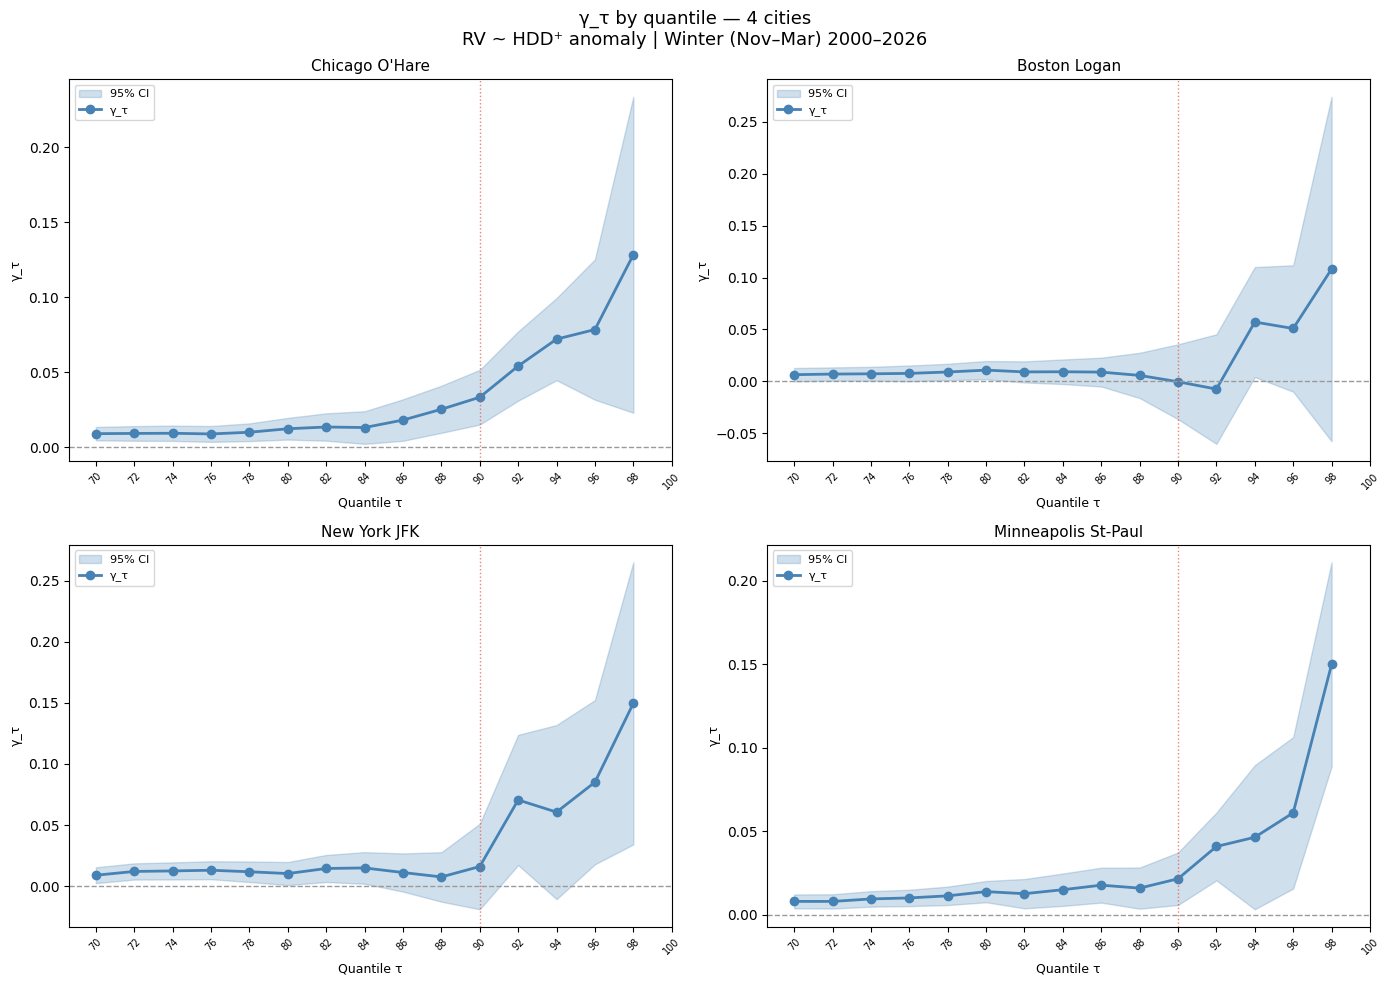

In [114]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

quantiles = np.arange(0.70, 1.00, 0.02)

city_configs = {
    "Chicago O'Hare"     : 'HDD_anom_chicago',
    'Boston Logan'       : 'HDD_anom_boston',
    'New York JFK'       : 'HDD_anom_new_york',
    'Minneapolis St-Paul': 'HDD_anom_minneapolis',
}

for ax, (city_name, col) in zip(axes.flatten(), city_configs.items()):

    # Weekly dataset per city
    hdd_city = df_main[col].resample('W').sum()
    df_city  = pd.DataFrame({
        'RV'      : rv_weekly,
        'HDD_anom': hdd_city,
    }).dropna()
    df_city['month']     = df_city.index.month
    df_city['is_winter'] = df_city['month'].isin([11,12,1,2,3])

    df_w = df_city[
        df_city['is_winter'] &
        (df_city['HDD_anom'] > 0)
    ].copy()

    gammas, ci_low, ci_high = [], [], []

    for tau in quantiles:
        try:
            res = smf.quantreg('RV ~ HDD_anom', data=df_w).fit(q=tau, max_iter=2000)
            gammas.append(res.params['HDD_anom'])
            conf = res.conf_int()
            ci_low.append(conf.loc['HDD_anom', 0])
            ci_high.append(conf.loc['HDD_anom', 1])
        except:
            gammas.append(np.nan)
            ci_low.append(np.nan)
            ci_high.append(np.nan)

    ax.fill_between(quantiles, ci_low, ci_high,
                    alpha=0.25, color='steelblue', label='95% CI')
    ax.plot(quantiles, gammas, 'o-', color='steelblue',
            lw=2, ms=6, label='γ_τ')
    ax.axhline(0, color='#999', lw=1, ls='--')
    ax.axvline(0.90, color='#e74c3c', lw=1, ls=':', alpha=0.7)

    ax.set_title(city_name, fontsize=11)
    ax.set_xlabel('Quantile τ', fontsize=9)
    ax.set_ylabel('γ_τ', fontsize=9)
    ax.set_xticks(quantiles)
    ax.set_xticklabels([f'{int(q*100)}' for q in quantiles], rotation=45, fontsize=7)
    ax.legend(fontsize=8)

fig.suptitle('γ_τ by quantile - 4 cities\nRV ~ HDD⁺ anomaly | Winter (Nov to Mar) 2000 to 2026',
             fontsize=13)
plt.tight_layout()
plt.show()

As the plot of $\gamma_\tau$ by city shows, the coefficient is close to zero between Q50 and Q80. From there on, the value of the coefficient rises and is increasing in the quantiles, despite large uncertainty (few intense-winter events on record). This confirms that the HDD effect amplifies in high-volatility regimes, so the HDD-RV relationship is nonlinear. One caveat: the lack of data, and hence the very wide confidence intervals for the highest quantiles, precisely the ones we care about.

## Anomaly timing analysis

The $\gamma_\tau$ coefficients estimated above are global. They capture the average effect of HDD anomalies over the whole winter season. But a natural question arises: **does an HDD anomaly in November have the same impact on volatility as one occurring in February?**

To test this hypothesis, we re-estimate $\gamma_\tau$ on **rolling 6-week windows** across the winter season. Formally, for each window centred on week $s$:

$$\hat{\gamma}_\tau(s) = \arg\min_{\gamma} \sum_{t \in \mathcal{W}(s)} \rho_\tau\!\left(RV_t - \alpha - \gamma \cdot \widetilde{HDD}_{t}^{+,\text{agg}}\right)$$

where $\mathcal{W}(s)$ denotes the set of observations belonging to the 6 weeks centred around $s$, aggregated over all available years (2000 to 2026).

If $\hat{\gamma}_\tau(s)$ increases through the winter, that confirms that the HDD effect intensifies as storage runs down, which will be the direct empirical justification for the storage interaction in X\_hdd\_stock.

In [115]:
def winter_week(date):
    m = date.month
    offsets = {11: 0, 12: 4, 1: 9, 2: 13, 3: 17}
    if m not in offsets:
        return np.nan
    base = offsets[m]
    w = min((date.day - 1) // 7, 3)
    return base + w + 1

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


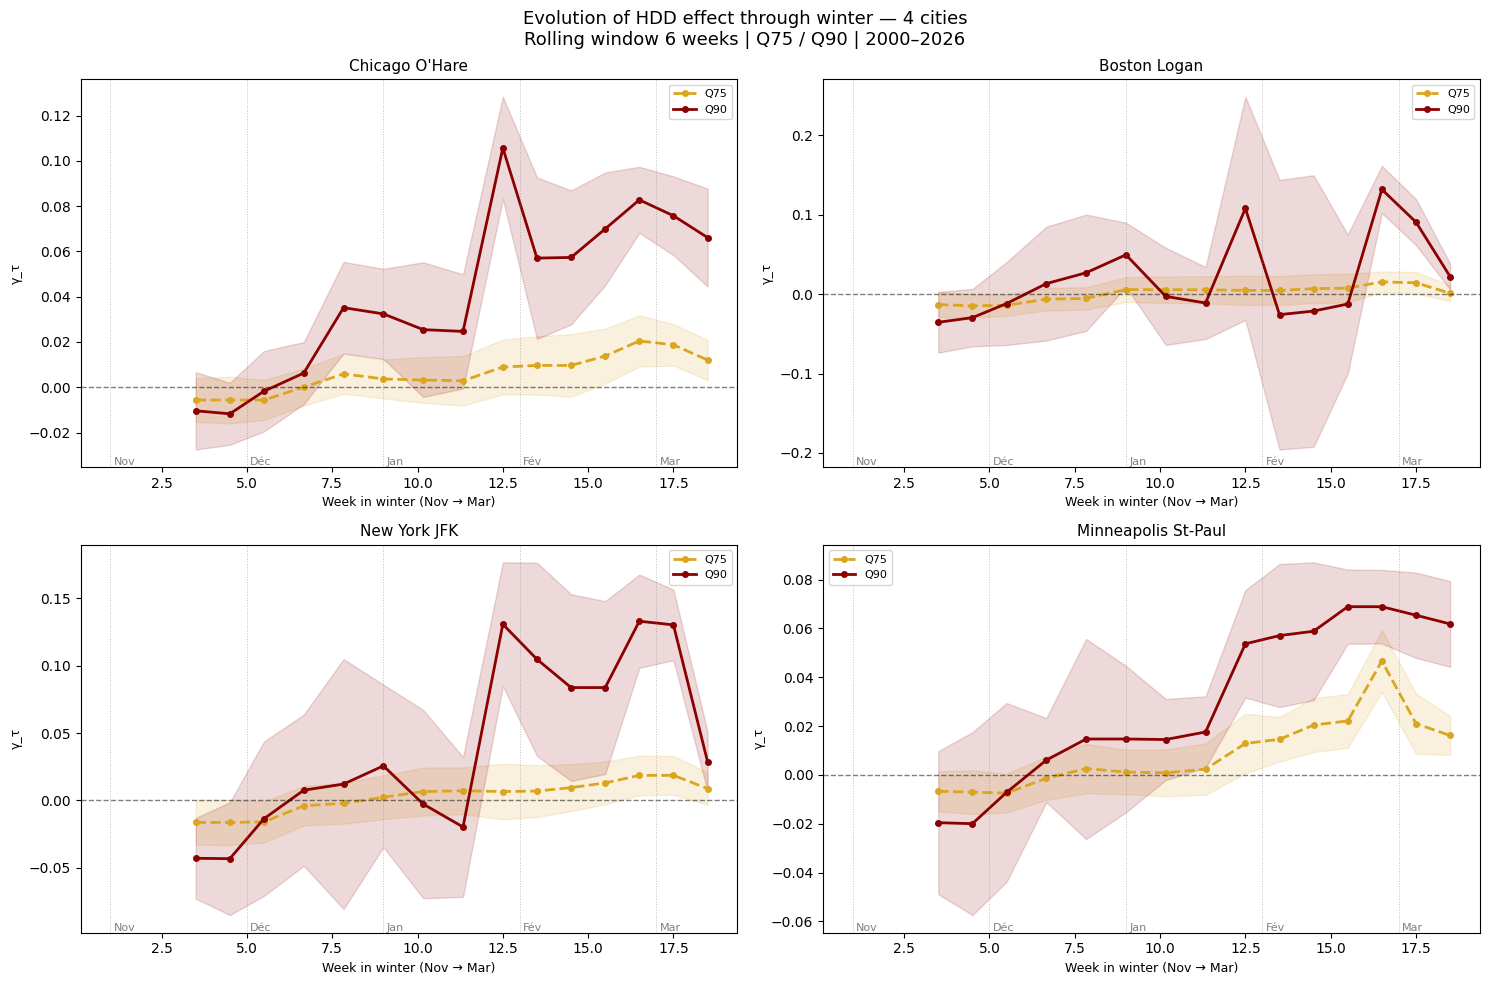

In [116]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

city_configs = {
    "Chicago O'Hare"     : 'HDD_anom_chicago',
    'Boston Logan'       : 'HDD_anom_boston',
    'New York JFK'       : 'HDD_anom_new_york',
    'Minneapolis St-Paul': 'HDD_anom_minneapolis',
}

tau_styles = {0.75: ('goldenrod', '--', 'Q75'),
              0.90: ('darkred',   '-',  'Q90')}

for ax, (city_name, col) in zip(axes.flatten(), city_configs.items()):

    # Weekly dataset per city
    hdd_city = df_main[col].resample('W').sum()
    df_city  = pd.DataFrame({
        'RV'           : rv_weekly,
        'HDD_anom_lag1': hdd_city.shift(1),
    }).dropna()
    df_city['month']     = df_city.index.month
    df_city['is_winter'] = df_city['month'].isin([11,12,1,2,3])

    df_pos = df_city[
        df_city['is_winter'] &
        (df_city['HDD_anom_lag1'] > 0)
    ].copy()
    df_pos['winter_week'] = df_pos.index.map(winter_week)

    results = []
    weeks  = sorted(df_pos['winter_week'].unique())
    window = 6

    for i in range(len(weeks) - window + 1):
        w_slice = weeks[i:i+window]
        sub = df_pos[df_pos['winter_week'].isin(w_slice)]
        if len(sub) < 25:
            continue
        center_week = np.mean(w_slice)
        for tau in [0.75, 0.90]:
            try:
                res = smf.quantreg('RV ~ HDD_anom_lag1', data=sub).fit(
                    q=tau, max_iter=2000)
                g    = res.params['HDD_anom_lag1']
                conf = res.conf_int()
                results.append({
                    'week'   : center_week,
                    'tau'    : tau,
                    'gamma'  : g,
                    'ci_low' : conf.loc['HDD_anom_lag1', 0],
                    'ci_high': conf.loc['HDD_anom_lag1', 1]
                })
            except:
                pass

    df_res = pd.DataFrame(results)

    for tau, (color, ls, label) in tau_styles.items():
        sub = df_res[df_res['tau'] == tau].sort_values('week')
        ax.fill_between(sub['week'], sub['ci_low'], sub['ci_high'],
                        alpha=0.15, color=color)
        ax.plot(sub['week'], sub['gamma'], color=color, lw=2,
                ls=ls, marker='o', ms=4, label=label)

    ax.axhline(0, color='black', lw=1, ls='--', alpha=0.5)
    for w, lbl in [(1,'Nov'),(5,'Dec'),(9,'Jan'),(13,'Feb'),(17,'Mar')]:
        ax.axvline(w, color='grey', lw=0.7, ls=':', alpha=0.5)
        ax.text(w + 0.1, ax.get_ylim()[0] if len(results) > 0 else 0,
                lbl, fontsize=8, color='grey', va='bottom')

    ax.set_title(city_name, fontsize=11)
    ax.set_xlabel('Week in winter (Nov to Mar)', fontsize=9)
    ax.set_ylabel('γ_τ', fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle('Evolution of HDD effect through winter - 4 cities\n'
             'Rolling window 6 weeks | Q75 / Q90 | 2000 to 2026',
             fontsize=13)
plt.tight_layout()
plt.show()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


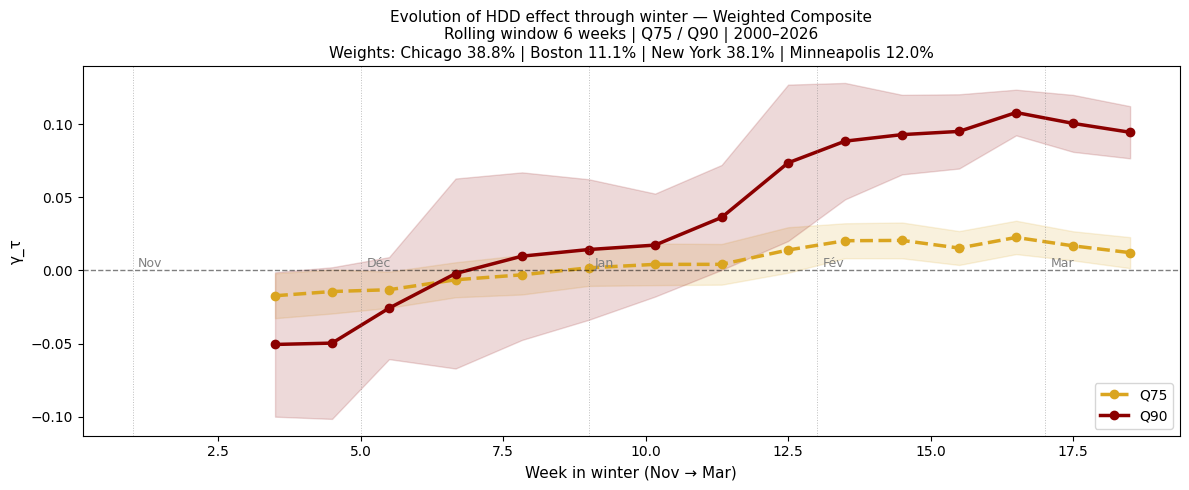

In [117]:
# Weighted Composite only
col = 'HDD_anom_weighted'

hdd_city = df_main[col].resample('W').sum()
df_city  = pd.DataFrame({
    'RV'           : rv_weekly,
    'HDD_anom_lag1': hdd_city.shift(1),
}).dropna()
df_city['month']     = df_city.index.month
df_city['is_winter'] = df_city['month'].isin([11,12,1,2,3])

df_pos = df_city[
    df_city['is_winter'] &
    (df_city['HDD_anom_lag1'] > 0)
].copy()
df_pos['winter_week'] = df_pos.index.map(winter_week)

results = []
weeks   = sorted(df_pos['winter_week'].unique())
window  = 6

for i in range(len(weeks) - window + 1):
    w_slice = weeks[i:i+window]
    sub = df_pos[df_pos['winter_week'].isin(w_slice)]
    if len(sub) < 25:
        continue
    center_week = np.mean(w_slice)
    for tau in [0.75, 0.90]:
        try:
            res = smf.quantreg('RV ~ HDD_anom_lag1', data=sub).fit(
                q=tau, max_iter=2000)
            g    = res.params['HDD_anom_lag1']
            conf = res.conf_int()
            results.append({
                'week'   : center_week,
                'tau'    : tau,
                'gamma'  : g,
                'ci_low' : conf.loc['HDD_anom_lag1', 0],
                'ci_high': conf.loc['HDD_anom_lag1', 1]
            })
        except:
            pass

df_res = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 5))

tau_styles = {0.75: ('goldenrod', '--', 'Q75'),
              0.90: ('darkred',   '-',  'Q90')}

for tau, (color, ls, label) in tau_styles.items():
    sub = df_res[df_res['tau'] == tau].sort_values('week')
    ax.fill_between(sub['week'], sub['ci_low'], sub['ci_high'],
                    alpha=0.15, color=color)
    ax.plot(sub['week'], sub['gamma'], color=color, lw=2.5,
            ls=ls, marker='o', ms=6, label=label)

ax.axhline(0, color='black', lw=1, ls='--', alpha=0.5)
for w, lbl in [(1,'Nov'),(5,'Dec'),(9,'Jan'),(13,'Feb'),(17,'Mar')]:
    ax.axvline(w, color='grey', lw=0.7, ls=':', alpha=0.5)
    ax.text(w + 0.1, 0, lbl, fontsize=9, color='grey', va='bottom')

ax.set_xlabel('Week in winter (Nov to Mar)', fontsize=11)
ax.set_ylabel('γ_τ', fontsize=11)
ax.set_title('Evolution of HDD effect through winter - Weighted Composite\n'
             f'Rolling window 6 weeks | Q75 / Q90 | 2000 to 2026\n'
             f'Weights: Chicago {weights["chicago"]*100:.1f}% | '
             f'Boston {weights["boston"]*100:.1f}% | '
             f'New York {weights["new_york"]*100:.1f}% | '
             f'Minneapolis {weights["minneapolis"]*100:.1f}%',
             fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The results confirm our intuition: between November and December, $\gamma_\tau$ stays close to zero regardless of the quantile considered. From January onward, $\gamma_{90\%}$ becomes significantly positive, peaks in February (~0.10 on the weighted composite), then declines slightly in March as heating demand starts to fall.

What could this be due to? In early winter, gas storage is fully supplied and at its highest. The market has a safety cushion that absorbs demand shocks without price strain. Conversely, as winter progresses, storage is gradually consumed. If a strong anomaly hits late in the season, one would be forced to source at the spot price to make up for it, amplifying volatility disproportionately.

This mechanism justifies the introduction of a storage interaction variable in our GARCH-X model. A constant $\gamma$ over the whole season would be a misspecification: it would over-estimate the HDD effect in November and under-estimate it in February, precisely where getting it wrong is most costly for pricing.

## NG Stock Analysis

In this section, we explore the link between gas storage and its volatility. As before, the data used here are available on the EIA website: http://www.eia.gov/dnav/ng/ng_cons_sum_a_epg0_vrs_mmcf_a.htm.

In [118]:
df_inv = pd.read_excel(
    '../data/ngs_stocks.xls',
    engine='xlrd', sheet_name=0, header=5
)

In [119]:
df_inv = pd.read_excel(
    '../data/ngs_stocks.xls',
    engine='xlrd', sheet_name=0, header=5
)

# Rename and keep only the useful columns
df_inv = df_inv.rename(columns={df_inv.columns[0]: 'date', df_inv.columns[-1]: 'total_bcf'})
df_inv = df_inv[['date', 'total_bcf']]

# Clean
df_inv['date']      = pd.to_datetime(df_inv['date'], errors='coerce')
df_inv['total_bcf'] = pd.to_numeric(df_inv['total_bcf'], errors='coerce')
df_inv = (df_inv
          .dropna(subset=['date', 'total_bcf'])
          .sort_values('date')
          .set_index('date'))

# Weekly frequency W-FRI
df_inv = df_inv.resample('W-FRI').last().dropna()

# Calendar week
df_inv['week'] = df_inv.index.isocalendar().week.astype(int)

# Seasonal normal over 2010-2019, dict for map
inv_normal_dict = (df_inv
                   .loc['2010':'2019']
                   .groupby('week')['total_bcf']
                   .mean()
                   .to_dict())

# Map preserves the DatetimeIndex
df_inv['inv_normal'] = df_inv['week'].map(inv_normal_dict)

# Relative anomaly
df_inv['inv_tilde'] = (df_inv['total_bcf'] - df_inv['inv_normal']) / df_inv['inv_normal']

# Weekly change
df_inv['delta_inv'] = df_inv['total_bcf'].diff()

print(f"df_inv : {len(df_inv)} observations | {df_inv.index.min().date()} -> {df_inv.index.max().date()}")
print(df_inv[['total_bcf', 'inv_normal', 'inv_tilde', 'delta_inv']].describe().round(3))

df_inv : 855 observations | 2010-01-01 → 2026-05-15
       total_bcf  inv_normal  inv_tilde  delta_inv
count    855.000     855.000    855.000    854.000
mean    2758.353    2709.558      0.021     -0.850
std      740.328     684.871      0.148     99.128
min      824.000    1670.700     -0.509   -359.000
25%     2204.000    2068.600     -0.052    -62.750
50%     2810.000    2738.500      0.026     34.500
75%     3359.000    3315.500      0.098     76.000
max     4047.000    3781.600      0.484    132.000


In this dataframe `df_inv`, we have the required gas-storage data with $I_t$ the gas stock at time $t$ in Bcf (Billions of Cubic Feet, the reference volume unit used by the North American gas industry): $1 \text{ Bcf} \approx 28.32 \text{ million cubic metres } (Mm^3)$

We introduce the following variables:
- $\Delta I_t = I_t - I_{t-1}$: change in gas stock at time $t$
- $\tilde{I_t} =\frac{I_t - \bar{I_{w}}}{\bar{I_{w}}}$: the gas-storage anomaly relative to the weekly mean $\bar{I_{w}}$

In [120]:
df_inv.head()

,total_bcf,week,inv_normal,inv_tilde,delta_inv
date,,,,,
2010-01-01,3117.0,53,3380.0,-0.077811,NaN
2010-01-08,2850.0,1,3042.5,-0.063270,-267.0
2010-01-15,2607.0,2,2849.4,-0.085071,-243.0
2010-01-22,2521.0,3,2676.9,-0.058239,-86.0
2010-01-29,2406.0,4,2529.5,-0.048824,-115.0


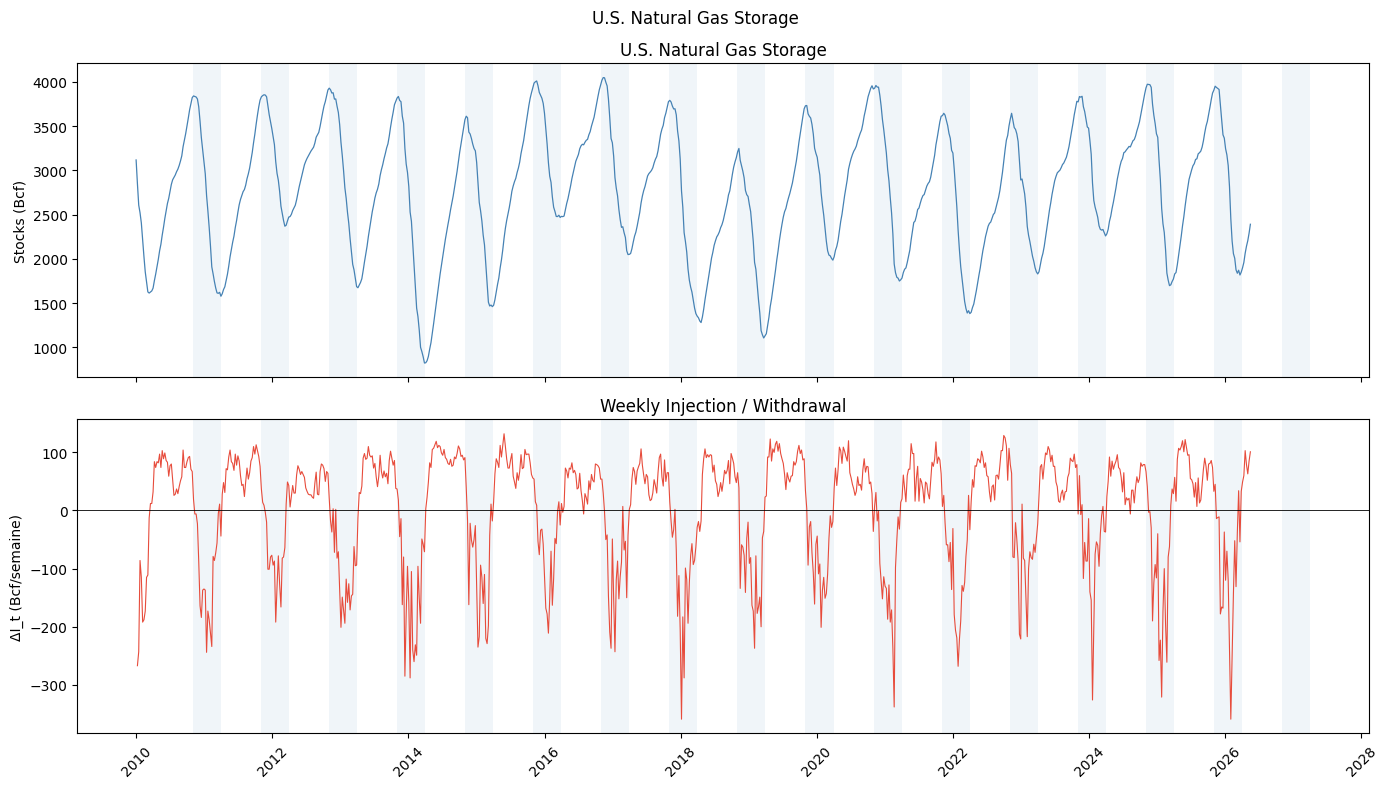

In [121]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_inv.index, df_inv['total_bcf'], color='steelblue', lw=0.9)
axes[0].set_ylabel('Stocks (Bcf)')
axes[0].set_title('U.S. Natural Gas Storage')

axes[1].plot(df_inv.index, df_inv['delta_inv'], color='#e74c3c', lw=0.8)
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_ylabel('ΔI_t (Bcf/week)')
axes[1].set_title('Weekly Injection / Withdrawal')

# Winter bands Nov-Mar
for ax in axes:
    for year in range(df_inv.index.year.min(), df_inv.index.year.max() + 1):
        try:
            ax.axvspan(
                pd.Timestamp(f'{year}-11-01'),
                pd.Timestamp(f'{year+1}-03-31'),
                alpha=0.08, color='steelblue', lw=0
            )
        except Exception:
            pass
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)
fig.suptitle('U.S. Natural Gas Storage', fontsize=12)
plt.tight_layout()
plt.show()

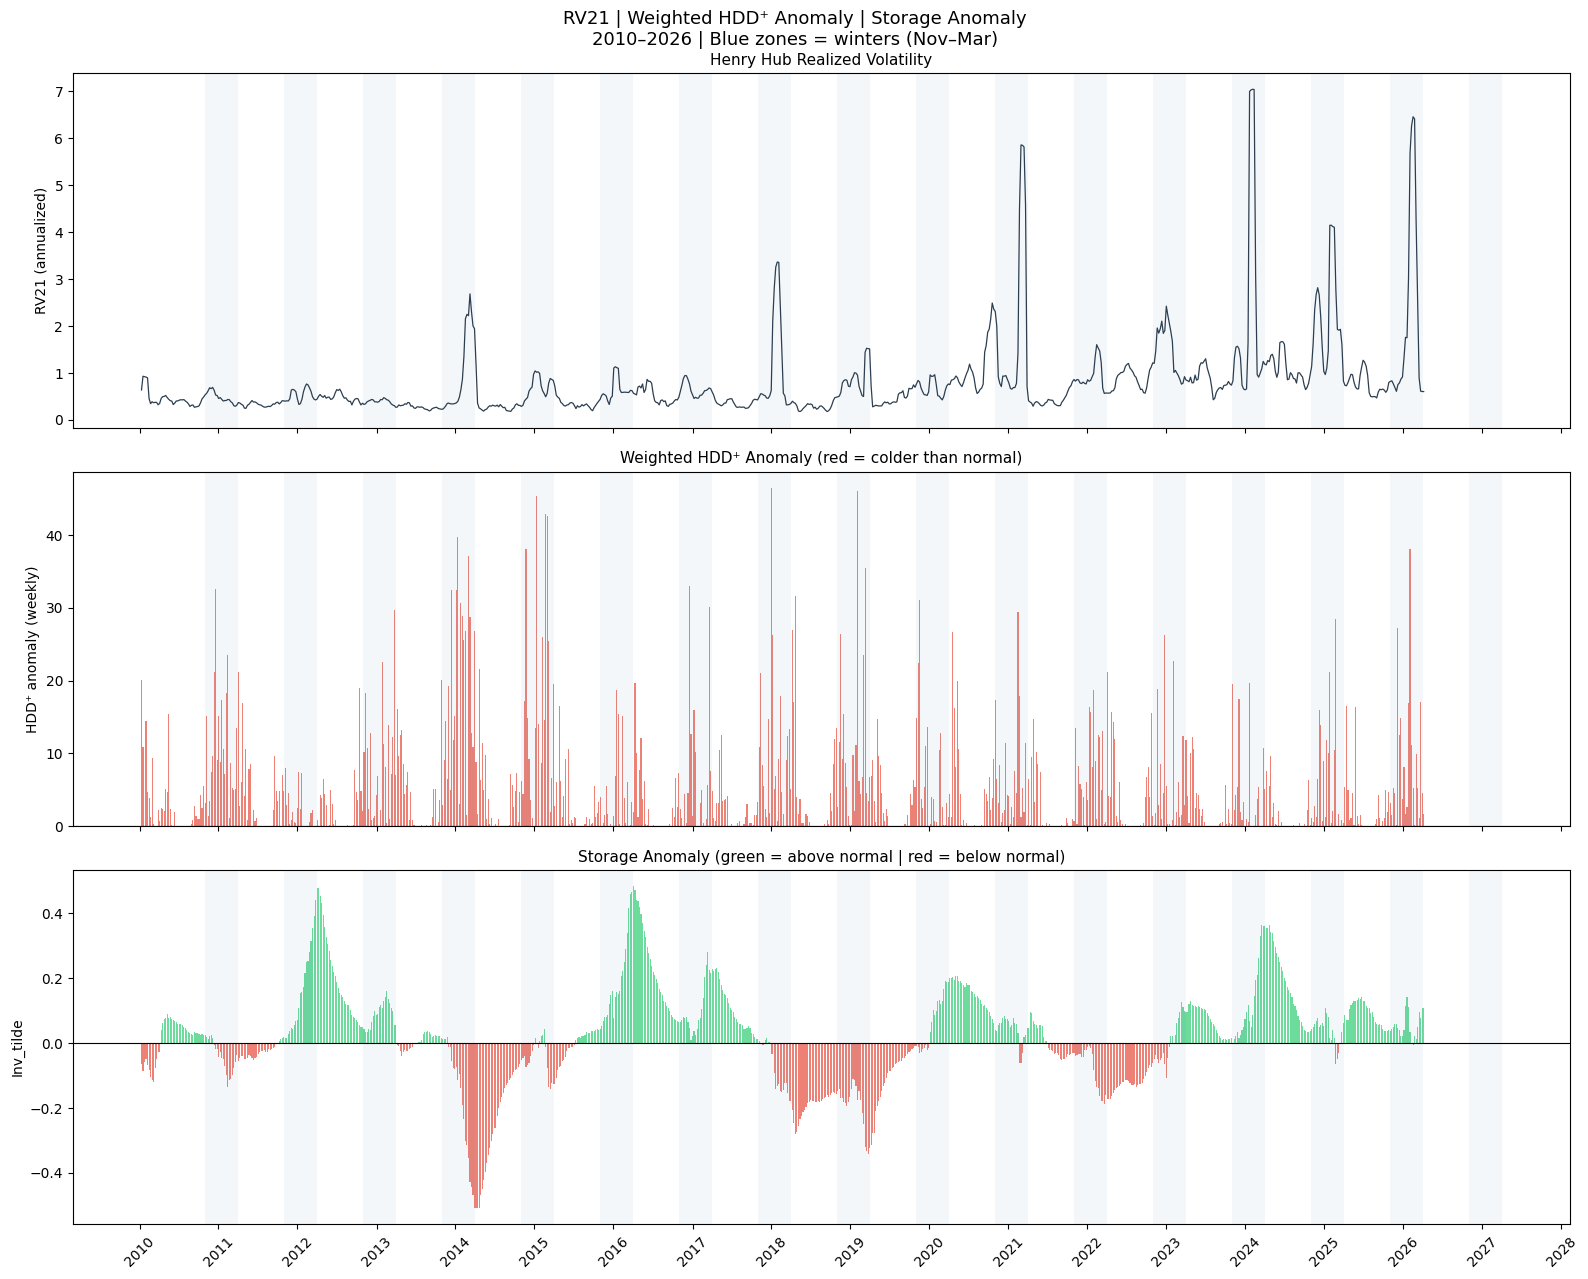

In [122]:
# -----------------------------------------------------------
# RV21 + HDD anomaly + Storage anomaly - 3 panels
# -----------------------------------------------------------

df_inv_daily = df_inv[['inv_tilde']].resample('D').ffill()
df_main['inv_tilde'] = df_inv_daily['inv_tilde']

df_weekly_main = pd.DataFrame({
    'RV21'             : df_main['RV21'].resample('W').mean(),
    'HDD_anom_weighted': df_main['HDD_anom_weighted'].resample('W').sum(),
    'inv_tilde'        : df_main['inv_tilde'].resample('W').last(),
}).dropna()

df_weekly_main = df_weekly_main.loc['2010':'2026']

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

# --- Panel 1 : RV21 ---
ax = axes[0]
ax.plot(df_weekly_main.index, df_weekly_main['RV21'],
        color='#2c3e50', lw=0.9)
ax.set_ylabel('RV21 (annualized)', fontsize=10)
ax.set_title('Henry Hub Realized Volatility', fontsize=11)

# --- Panel 2 : HDD anomaly ---
ax = axes[1]
hdd = df_weekly_main['HDD_anom_weighted']
colors_hdd = ['#e74c3c' if v >= 0 else '#2ecc71' for v in hdd]
ax.bar(df_weekly_main.index, hdd, color=colors_hdd, alpha=0.7, width=5)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('HDD⁺ anomaly (weekly)', fontsize=10)
ax.set_title('Weighted HDD⁺ Anomaly (red = colder than normal)', fontsize=11)

# --- Panel 3 : inv_tilde ---
ax = axes[2]
colors_inv = ['#2ecc71' if v >= 0 else '#e74c3c'
              for v in df_weekly_main['inv_tilde']]
ax.bar(df_weekly_main.index, df_weekly_main['inv_tilde'],
       color=colors_inv, alpha=0.7, width=5)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Inv_tilde', fontsize=10)
ax.set_title('Storage Anomaly (green = above normal | red = below normal)', fontsize=11)

# Winter bands + x axis
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    for year in range(2010, 2027):
        try:
            ax.axvspan(pd.Timestamp(f'{year}-11-01'),
                       pd.Timestamp(f'{year+1}-03-31'),
                       alpha=0.06, color='steelblue', lw=0)
        except Exception:
            pass

plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)
fig.suptitle('RV21 | Weighted HDD⁺ Anomaly | Storage Anomaly\n'
             '2010 to 2026 | Blue zones = winters (Nov to Mar)', fontsize=13)
plt.tight_layout()
plt.show()

The chart highlights a fundamental asymmetry in the transmission of temperature shocks to gas volatility. In late winter (January to March), storage is structurally depleted after several weeks of withdrawal. This is the regime where the market is most vulnerable.

However, not all late winters are alike. What determines the amplitude of the volatility *spikes* is not the absolute level of storage, but its level relative to the historical normal, captured by $\tilde{I}_t$:

* **$\tilde{I}_t > 0$ in late winter (2012, 2016):** Storage is depleted but stays above the historical averages. The market still has a safety net. A late cold shock generates volatility but remains absorbable, enough to keep things from running away.
* **$\tilde{I}_t < 0$ in late winter (2014, 2018, 2022):** Storage is below normal. The market anticipates a risk of physical shortfall. Even a moderate temperature anomaly is enough to make volatility explode. The most pronounced $RV_{21}$ *spikes* in the chart systematically correspond to these configurations.

## Analyses and model choice so far

Through these analyses, several conclusions emerge:

- An early-season winter anomaly (November to December) has a limited impact on natural-gas volatility. Since storage is generally at its maximum level after the injection season, the market has a sufficient buffer to absorb demand shocks.

- Only pronounced anomalies in the tails of the distribution have a significant impact on volatility. Empirically, the critical threshold sits around the 80 to 85% quantile of the HDD anomaly distribution.

- The sensitivity of volatility to temperature anomalies grows through the winter. The $\tau_{90}$ coefficient of our quantile regressions reaches its maximum in February, reflecting the progressive depletion of storage after several weeks of withdrawal.

- The moment of critical strain concentrates in late winter (January to March). The amplitude of the volatility spikes then depends on the relative level of storage compared with its historical normal: a storage deficit ($\tilde{I}_t < 0$) in late winter strongly amplifies the response of volatility to a cold shock, whereas a normal storage level attenuates this sensitivity. It is this interaction that motivates the specification of model C.

We can therefore test different types of coupling to assess the significance of the link between gas volatility, temperature anomalies and storage. For all three models, the mean equation reduces to:

$$r_t = \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \quad z_t \sim \mathcal{N}(0,1)$$

A Student test on the constant $\mu$ does not reject $H_0 : \mu = 0$, consistent with the absence of directional drift in natural-gas spot prices over the estimation period. (done in part 2, notebook 3)

---

**Model A (`Baseline`)**: GARCH(1,1) without exogenous variable, the reference model:

$$\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2$$

**Model B (`Anomaly coupling`)**: direct coupling between gas volatility and temperature anomalies:

$$\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2 + \gamma\widetilde{\text{HDD}}_t^+$$

**Model C (`Anomaly x Storage x Late winter coupling`)**:

$$\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2 + \gamma\widetilde{\text{HDD}}_t^+ + \delta \cdot \widetilde{\text{HDD}}_t^+ \cdot \max(-\tilde{I}_t, 0) \cdot \mathbf{1}_{\text{jan-mar}}$$

The additional term in model C captures a precise nonlinearity: the same cold shock $\widetilde{\text{HDD}}_t^+$ amplifies conditional variance only when two conditions are met simultaneously. First, storage must be below its historical normal ($\tilde{I}_t < 0$), signalling a physical buffer deficit. Second, the shock must occur in late winter ($\mathbf{1}_{\text{jan-mar}}$), the period when storage is at its lowest after several weeks of withdrawal and when the risk of a supply shortfall is greatest.

When these two conditions are met, the market prices a scarcity premium that amplifies the response of volatility to the weather shock. This is precisely what the previous chart illustrates for the winters of 2014, 2018 and 2022.

In [123]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
import numdifftools as nd

# ═════════════════════════════════════════════════════════════
# 1. BUILDING df_model
# ═════════════════════════════════════════════════════════════

r = df_main['log_ret'] * 100
hdd = df_main['HDD_anom_weighted'].clip(lower=0)

# daily inv_tilde
inv_tilde_daily = (df_inv[['inv_tilde']]
                   .resample('D').ffill()
                   .reindex(df_main.index)
                   .ffill())

# Model C interaction term
late_winter  = df_main.index.month.isin([1, 2, 3]).astype(float)
interaction  = (hdd
                * (-inv_tilde_daily['inv_tilde']).clip(lower=0)
                * late_winter)
interaction.name = 'interaction'

df_model = pd.concat([
    r.rename('r'),
    hdd.rename('hdd'),
    inv_tilde_daily['inv_tilde'],
    interaction,
], axis=1).dropna(subset=['r', 'hdd'])

# Winsorize
q01 = df_model['r'].quantile(0.01)
q99 = df_model['r'].quantile(0.99)
df_model['r'] = df_model['r'].clip(lower=q01, upper=q99)

print(f"df_model : {df_model.shape}")
print(f"Period   : {df_model.index.min().date()} to {df_model.index.max().date()}")
print(f"Non-zero interaction : {(df_model['interaction'] > 0).sum()} obs")

# ═════════════════════════════════════════════════════════════
# 2. SPLITS
# ═════════════════════════════════════════════════════════════

df_train = df_model.loc['1997':'2020'].dropna()
df_test  = df_model.loc['2021':].dropna()
print(f"\nTrain : {len(df_train)} obs | Test : {len(df_test)} obs")

# ═════════════════════════════════════════════════════════════
# 3. NORMALIZATION
# ═════════════════════════════════════════════════════════════

def norm_std(s):
    std = s[s > 0].std()
    return s / std if std > 1e-8 else s

hdd_n   = norm_std(df_train['hdd']).rename('hdd')
itx_n   = norm_std(df_train['interaction']).rename('interaction')

print(f"\nhdd_n range : {hdd_n.min():.3f} -> {hdd_n.max():.3f}")
print(f"itx_n range : {itx_n.min():.3f} -> {itx_n.max():.3f}")
print(f"itx non-nuls : {(itx_n > 0).sum()}")

# ═════════════════════════════════════════════════════════════
# 4. GARCH-X FUNCTIONS
# ═════════════════════════════════════════════════════════════

def compute_sigma2(params, r_arr, x_arrays):
    omega, alpha, beta = params[0], params[1], params[2]
    gammas = params[3:]
    n      = len(r_arr)
    sigma2 = np.zeros(n)
    sigma2[0] = np.var(r_arr)
    for t in range(1, n):
        sigma2[t] = omega + alpha * r_arr[t-1]**2 + beta * sigma2[t-1]
        for k, x in enumerate(x_arrays):
            sigma2[t] += gammas[k] * x[t]
        sigma2[t] = max(sigma2[t], 1e-8)
    return sigma2

def garch_x_loglik(params, r, exog_vars):
    sigma2 = compute_sigma2(params, r, exog_vars)
    return 0.5 * np.sum(np.log(2 * np.pi * sigma2) + r**2 / sigma2)

def fit_garch_x(r, exog_vars=[], label=''):
    r_arr    = r.values
    x_arrays = [x.values for x in exog_vars]
    n_exog   = len(exog_vars)
    n        = len(r_arr)

    p0     = [np.var(r_arr) * 0.05, 0.10, 0.85] + [0.01] * n_exog
    bounds = [(1e-6, None), (1e-6, 0.5), (1e-6, 0.9999)] + \
             [(0, None)] * n_exog
    cons   = {'type': 'ineq', 'fun': lambda p: 0.9999 - p[1] - p[2]}

    res = minimize(garch_x_loglik, p0,
                   args=(r_arr, x_arrays),
                   method='SLSQP', bounds=bounds,
                   constraints=cons,
                   options={'maxiter': 2000, 'ftol': 1e-12})

    params = res.x
    loglik = -res.fun
    k      = len(params)
    aic    = -2 * loglik + 2 * k
    bic    = -2 * loglik + k * np.log(n)

    try:
        H   = nd.Hessian(
            lambda p: garch_x_loglik(p, r_arr, x_arrays))(params)
        cov = np.linalg.inv(H)
        se  = np.sqrt(np.abs(np.diag(cov)))
    except Exception as e:
        print(f"  Hessian warning : {e}")
        se = np.full(k, np.nan)

    tstats = params / se
    pvals  = 2 * (1 - norm.cdf(np.abs(tstats)))

    param_names = ['omega', 'alpha', 'beta'] + \
                  [x.name if hasattr(x, 'name') else f'gamma_{i}'
                   for i, x in enumerate(exog_vars)]

    df_params = pd.DataFrame({
        'coef'   : params,
        'std err': se,
        't-stat' : tstats,
        'p-value': pvals
    }, index=param_names)

    sigma2 = compute_sigma2(params, r_arr, x_arrays)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(df_params.round(4).to_string())
    print(f"\n  Log-lik : {loglik:.2f} | AIC : {aic:.2f} | BIC : {bic:.2f}")
    print(f"  α + β   : {params[1] + params[2]:.4f}")
    print(f"  Convergence : {res.message}")

    return {
        'params' : df_params,
        'loglik' : loglik,
        'aic'    : aic,
        'bic'    : bic,
        'sigma2' : pd.Series(sigma2, index=r.index),
        'resid'  : pd.Series(r_arr / np.sqrt(sigma2), index=r.index),
        'res_raw': res
    }

# ═════════════════════════════════════════════════════════════
# 5. ESTIMATION A, B, C
# ═════════════════════════════════════════════════════════════

r_tr = df_train['r']

res_A = fit_garch_x(r_tr, exog_vars=[],
                    label='Model A - GARCH(1,1) baseline')

res_B = fit_garch_x(r_tr, exog_vars=[hdd_n],
                    label='Model B - GARCH-X HDD')

res_C = fit_garch_x(r_tr, exog_vars=[hdd_n, itx_n],
                    label='Model C - GARCH-X HDD x Storage x Late winter')

# ═════════════════════════════════════════════════════════════
# 6. COMPARISON TABLE
# ═════════════════════════════════════════════════════════════

rows = []
for name, res in [('A - Baseline',        res_A),
                  ('B - HDD',             res_B),
                  ('C - HDD x Stock x Winter', res_C)]:
    p  = res['params']['coef']
    pv = res['params']['p-value']
    row = {
        'Model'         : name,
        'ω'             : round(p['omega'], 4),
        'α'             : round(p['alpha'], 4),
        'β'             : round(p['beta'],  4),
        'α+β'           : round(p['alpha'] + p['beta'], 4),
        'γ'             : round(p.get('hdd', np.nan), 4),
        'γ p-val'       : round(pv.get('hdd', np.nan), 3),
        'δ'             : round(p.get('interaction', np.nan), 4),
        'δ p-val'       : round(pv.get('interaction', np.nan), 3),
        'Log-lik'       : round(res['loglik'], 1),
        'AIC'           : round(res['aic'], 1),
        'BIC'           : round(res['bic'], 1),
    }
    rows.append(row)

df_comp = pd.DataFrame(rows).set_index('Model').fillna('-')
print("\n=== COMPARISON TABLE A / B / C ===")
print(df_comp.to_string())

df_model : (7318, 4)
Période  : 1997-02-06 → 2026-04-01
Interaction non-nulle : 349 obs

Train : 2785 obs | Test : 1310 obs

hdd_n range : 0.000 → 6.702
itx_n range : 0.000 → 5.485
itx non-nuls : 276

  Modèle A — GARCH(1,1) baseline
         coef  std err   t-stat  p-value
omega  0.2668   0.0572   4.6605      0.0
alpha  0.1164   0.0116  10.0077      0.0
beta   0.8659   0.0127  67.9218      0.0

  Log-lik : -7122.10 | AIC : 14250.19 | BIC : 14267.99
  α + β   : 0.9823
  Convergence : Optimization terminated successfully

  Modèle B — GARCH-X HDD
         coef  std err   t-stat  p-value
omega  0.2354   0.0550   4.2811   0.0000
alpha  0.1134   0.0115   9.8959   0.0000
beta   0.8623   0.0130  66.1765   0.0000
hdd    0.1978   0.0697   2.8388   0.0045

  Log-lik : -7116.67 | AIC : 14241.34 | BIC : 14265.07
  α + β   : 0.9757
  Convergence : Optimization terminated successfully

  Modèle C — GARCH-X HDD × Stocks × Fin hiver
               coef  std err   t-stat  p-value
omega        0.2354  

Here we want to compare the coupling models with baseline A, using AIC and BIC as selection criteria, two standard metrics in the GARCH literature.

| Model | $\omega$ | $\alpha$ | $\beta$ | $\alpha+\beta$ | $\gamma$ (p-val) | $\delta$ (p-val) | AIC | BIC |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **A - Baseline** | 0.267 | 0.116 | 0.866 | 0.982 | - | - | 14250.2 | 14268.0 |
| **B - GARCH-X HDD** | 0.235 | 0.113 | 0.862 | 0.976 | 0.198 (0.005) | - | 14241.3 | 14265.1 |
| **C - GARCH-X HDD×Stock** | 0.235 | 0.113 | 0.862 | 0.976 | 0.198 (0.007) | 0.000 (1.000) | 14243.3 | 14273.0 |

**Model B**: The coefficient $\hat{\gamma} = 0.198$ is significant (p = 0.005), confirming the existence of a coupling between temperature anomalies and conditional variance. The AIC of model B (14241.3) is 9 points lower than that of the baseline (14250.2), and the BIC confirms this result (14265.1 vs 14268.0). The persistence $\hat{\alpha} + \hat{\beta} = 0.976$ decreases slightly relative to the baseline (0.982). Part of the persistent variance was in fact seasonal weather volatility absorbed by the GARCH term in the absence of an exogenous variable. Model B is retained as the reference specification for the weather-volatility coupling.

**Model C**: The parameter $\hat{\delta} = 0$ is not significant (p = 1.000) and the log-likelihood is identical to that of model B to the fourth decimal. The AIC of model C (14243.3) is higher than that of B. The extra parameter does not offset its lack of contribution to the likelihood.

This result does not mean the storage effect is economically absent. Two structural factors explain the non-identification of $\delta$:

1. **Data problem**: The episodes where the three conditions are met simultaneously (positive cold anomaly, storage below normal ($\tilde{I}_t < 0$), and month from January to March) account for 276 observations out of 2785 in the train set, that is less than 10% of the sample.
2. **Absorption by persistence**: With $\hat{\beta} = 0.862$, late-winter variance is already high through $\beta\sigma_{t-1}^2$, inherited from early-winter shocks. The optimizer finds no residual signal to attribute to $\delta$.

These results motivate a reformulation of **model C** to observe the timing of the $HDD$ effects:

## New candidates

For the rest of our tests, we keep **models A and B**, and we continue running tests to understand the interactions.

Let us introduce an explicit influence of temperature anomalies on the coupling model, by creating $\gamma$ coefficients specific to each winter period. **Model D** distinguishes the effect of early-winter anomalies (November to December) from that of late-winter anomalies (January to March):

$$\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2 + \gamma_{\text{early}}\widetilde{\text{HDD}}_t^+ \cdot \mathbf{1}_{t \in \{\text{nov, dec}\}} + \gamma_{\text{late}}\widetilde{\text{HDD}}_t^+ \cdot \mathbf{1}_{t \in \{\text{jan, feb, mar}\}}$$

We want to see whether the same cold shock $\widetilde{\text{HDD}}_t^+$ has a different impact on conditional variance depending on the position in the winter cycle. In early winter, storage is full and the market has a sufficient *buffer*. The effect on volatility is potentially different from that observed in late winter, when storage is at its lowest after several weeks of withdrawal.

Model D thus lets us test the hypothesis:
$$H_0 : \gamma_{\text{early}} = \gamma_{\text{late}}$$

In [124]:
# ═════════════════════════════════════════════════════════════
# MODEL D - GARCH-X gamma_early / gamma_late
# ═════════════════════════════════════════════════════════════

# Exogenous variables
hdd_early_d = (df_model['hdd'] * 
               df_model.index.month.isin([11, 12]).astype(float))
hdd_late_d  = (df_model['hdd'] * 
               df_model.index.month.isin([1, 2, 3]).astype(float))
hdd_early_d.name = 'hdd_early'
hdd_late_d.name  = 'hdd_late'

# Normalize on the train set
early_n = norm_std(hdd_early_d.loc[df_train.index]).rename('hdd_early')
late_n  = norm_std(hdd_late_d.loc[df_train.index]).rename('hdd_late')

print(f"early_n non-nuls : {(early_n > 0).sum()} | range : {early_n.max():.3f}")
print(f"late_n  non-nuls : {(late_n  > 0).sum()} | range : {late_n.max():.3f}")

# Estimation
res_D = fit_garch_x(
    df_train['r'],
    exog_vars=[early_n, late_n],
    label='Model D - GARCH-X gamma_early / gamma_late'
)

# ─────────────────────────────────────────────────────────────
# Test H0 : gamma_early = gamma_late (Wald test)
# ─────────────────────────────────────────────────────────────
p      = res_D['params']['coef']
se     = res_D['params']['std err']

gamma_early = p['hdd_early']
gamma_late  = p['hdd_late']
se_early    = se['hdd_early']
se_late     = se['hdd_late']

# Wald stat : (gamma_early - gamma_late) / sqrt(se_early² + se_late²)
# Assumption : zero covariance between the two estimators
diff    = gamma_early - gamma_late
se_diff = np.sqrt(se_early**2 + se_late**2)
wald    = diff / se_diff
pval    = 2 * (1 - norm.cdf(abs(wald)))

print(f"\n=== Test H0 : gamma_early = gamma_late ===")
print(f"gamma_early = {gamma_early:.4f} (se = {se_early:.4f})")
print(f"gamma_late  = {gamma_late:.4f}  (se = {se_late:.4f})")
print(f"Difference = {diff:.4f}")
print(f"Wald stat  = {wald:.4f}")
print(f"p-value    = {pval:.4f}")
if pval < 0.05:
    print("-> H0 rejected : gamma_early != gamma_late (significant at 5%)")
else:
    print("-> H0 not rejected : gamma_early = gamma_late (not significant)")

# ─────────────────────────────────────────────────────────────
# Comparison table A / B / D
# ─────────────────────────────────────────────────────────────
rows = []
for name, res in [('A - Baseline',   res_A),
                  ('B - HDD',        res_B),
                  ('D - early/late', res_D)]:
    p  = res['params']['coef']
    pv = res['params']['p-value']
    row = {
        'Model'           : name,
        'ω'               : round(p['omega'], 4),
        'α'               : round(p['alpha'], 4),
        'β'               : round(p['beta'],  4),
        'α+β'             : round(p['alpha'] + p['beta'], 4),
        'γ_early (p-val)' : f"{p.get('hdd_early', float('nan')):.4f} "
                            f"({pv.get('hdd_early', float('nan')):.3f})"
                            if 'hdd_early' in p.index else '-',
        'γ_late (p-val)'  : f"{p.get('hdd_late', float('nan')):.4f} "
                            f"({pv.get('hdd_late', float('nan')):.3f})"
                            if 'hdd_late' in p.index else '-',
        'γ (p-val)'       : f"{p.get('hdd', float('nan')):.4f} "
                            f"({pv.get('hdd', float('nan')):.3f})"
                            if 'hdd' in p.index else '-',
        'Log-lik'         : round(res['loglik'], 1),
        'AIC'             : round(res['aic'], 1),
        'BIC'             : round(res['bic'], 1),
    }
    rows.append(row)

df_comp = pd.DataFrame(rows).set_index('Model')
print("\n=== COMPARISON TABLE A / B / D ===")
print(df_comp.to_string())

early_n non-nuls : 342 | range : 5.110
late_n  non-nuls : 477 | range : 5.294

  Modèle D — GARCH-X γ_early / γ_late
             coef  std err   t-stat  p-value
omega      0.2832   0.0582   4.8684   0.0000
alpha      0.1095   0.0115   9.5412   0.0000
beta       0.8610   0.0138  62.3430   0.0000
hdd_early  0.6181   0.1912   3.2330   0.0012
hdd_late   0.1899   0.1246   1.5232   0.1277

  Log-lik : -7110.60 | AIC : 14231.19 | BIC : 14260.85
  α + β   : 0.9705
  Convergence : Optimization terminated successfully

=== Test H0 : γ_early = γ_late ===
γ_early = 0.6181 (se = 0.1912)
γ_late  = 0.1899  (se = 0.1246)
Différence = 0.4282
Wald stat  = 1.8763
p-value    = 0.0606
→ H0 non rejetée : γ_early = γ_late (non significatif)

=== TABLEAU COMPARATIF A / B / D ===
                     ω       α       β     α+β γ_early (p-val)  γ_late (p-val)       γ (p-val)  Log-lik      AIC      BIC
Modèle                                                                                                         

The results obtained are rather puzzling: contrary to what we expected from the analyses in the sections above, it is indeed the early-winter coefficient that gives the model information.

This coefficient ($\hat{\gamma}_{\text{early}} = 0.618$) is significant at the 1% level (p = 0.001): cold anomalies in November to December have a direct and strong impact on conditional variance. Conversely, $\hat{\gamma}_{\text{late}} = 0.190$ is not significant (p = 0.128). Late-winter variance is already explained by the GARCH persistence through $\hat{\beta} = 0.861$. The Wald test on $H_0 : \gamma_{\text{early}} = \gamma_{\text{late}}$ gives a p-value of 0.061. We do not formally reject equality at 5%, but the difference $\hat{\gamma}_{\text{early}} - \hat{\gamma}_{\text{late}} = 0.428$ stays fairly high. The early-winter shock has an impact on conditional variance more than three times that of the late-winter shock.

To see why $\hat{\gamma}_{\text{late}}$ is so weakly significant, we run a variant of the model but in ARCH-X, keeping only the shock effects and the timing split:

$$\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \gamma_{\text{early}}\widetilde{\text{HDD}}_t^+ \cdot \mathbf{1}_{t \in \{\text{nov, dec}\}} + \gamma_{\text{late}}\widetilde{\text{HDD}}_t^+ \cdot \mathbf{1}_{t \in \{\text{jan, feb, mar}\}}$$

In [125]:
def fit_arch_x(r, exog_vars=[], label=''):
    """ARCH(1)-X : same interface as fit_garch_x but without beta"""
    r_arr    = r.values
    x_arrays = [x.values for x in exog_vars]
    n_exog   = len(exog_vars)
    n        = len(r_arr)

    def compute_sigma2_arch(params, r_arr, x_arrays):
        omega, alpha = params[0], params[1]
        gammas = params[2:]
        sigma2 = np.zeros(len(r_arr))
        sigma2[0] = np.var(r_arr)
        for t in range(1, len(r_arr)):
            sigma2[t] = omega + alpha * r_arr[t-1]**2
            for k, x in enumerate(x_arrays):
                sigma2[t] += gammas[k] * x[t]
            sigma2[t] = max(sigma2[t], 1e-8)
        return sigma2

    def loglik(params):
        sigma2 = compute_sigma2_arch(params, r_arr, x_arrays)
        return 0.5 * np.sum(np.log(2 * np.pi * sigma2) + r_arr**2 / sigma2)

    p0     = [np.var(r_arr) * 0.05, 0.10] + [0.01] * n_exog
    bounds = [(1e-6, None), (1e-6, 0.9999)] + [(0, None)] * n_exog

    res = minimize(loglik, p0, method='SLSQP', bounds=bounds,
                   options={'maxiter': 2000, 'ftol': 1e-12})

    params = res.x
    loglik_val = -res.fun
    k   = len(params)
    aic = -2 * loglik_val + 2 * k
    bic = -2 * loglik_val + k * np.log(n)

    try:
        H   = nd.Hessian(loglik)(params)
        cov = np.linalg.inv(H)
        se  = np.sqrt(np.abs(np.diag(cov)))
    except Exception as e:
        print(f"  Hessian warning : {e}")
        se = np.full(k, np.nan)

    tstats = params / se
    pvals  = 2 * (1 - norm.cdf(np.abs(tstats)))

    param_names = ['omega', 'alpha'] + \
                  [x.name if hasattr(x, 'name') else f'gamma_{i}'
                   for i, x in enumerate(exog_vars)]

    df_params = pd.DataFrame({
        'coef'   : params,
        'std err': se,
        't-stat' : tstats,
        'p-value': pvals
    }, index=param_names)

    sigma2 = compute_sigma2_arch(params, r_arr, x_arrays)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(df_params.round(4).to_string())
    print(f"\n  Log-lik : {loglik_val:.2f} | AIC : {aic:.2f} | BIC : {bic:.2f}")
    print(f"  Convergence : {res.message}")

    return {
        'params' : df_params,
        'loglik' : loglik_val,
        'aic'    : aic,
        'bic'    : bic,
        'sigma2' : pd.Series(sigma2, index=r.index),
        'resid'  : pd.Series(r_arr / np.sqrt(sigma2), index=r.index),
        'res_raw': res
    }

# ─────────────────────────────────────────────────────────────
# Estimation D'
# ─────────────────────────────────────────────────────────────
res_D_arch = fit_arch_x(
    df_train['r'],
    exog_vars=[early_n, late_n],
    label="Model D' - ARCH(1)-X early/late (without beta)"
)

# Test H0 : gamma_early = gamma_late
p_arch  = res_D_arch['params']['coef']
se_arch = res_D_arch['params']['std err']
pv_arch = res_D_arch['params']['p-value']

diff    = p_arch['hdd_early'] - p_arch['hdd_late']
se_diff = np.sqrt(se_arch['hdd_early']**2 + se_arch['hdd_late']**2)
wald    = diff / se_diff
pval    = 2 * (1 - norm.cdf(abs(wald)))

print(f"\n=== Test H0 : gamma_early = gamma_late ===")
print(f"gamma_early = {p_arch['hdd_early']:.4f} (p = {pv_arch['hdd_early']:.3f})")
print(f"gamma_late  = {p_arch['hdd_late']:.4f}  (p = {pv_arch['hdd_late']:.3f})")
print(f"Difference = {diff:.4f} | Wald = {wald:.4f} | p-val = {pval:.4f}")

# Comparison table D vs D'
print(f"\n=== GARCH-X D vs ARCH(1)-X D' ===")
print(f"{'':20} {'GARCH-X D':>20} {'ARCH(1)-X D':>20}")
print("-"*60)
for param in ['omega', 'alpha', 'hdd_early', 'hdd_late']:
    g_val = f"{res_D['params']['coef'].get(param, float('nan')):.4f} " \
            f"(p={res_D['params']['p-value'].get(param, float('nan')):.3f})"
    a_val = f"{p_arch.get(param, float('nan')):.4f} " \
            f"(p={pv_arch.get(param, float('nan')):.3f})"
    print(f"  {param:18} {g_val:>22} {a_val:>22}")
print(f"  {'beta':18} {'0.8610':>22} {'-':>22}")
print("-"*60)
print(f"  {'AIC':18} {res_D['aic']:>22.1f} {res_D_arch['aic']:>22.1f}")
print(f"  {'BIC':18} {res_D['bic']:>22.1f} {res_D_arch['bic']:>22.1f}")
print(f"  {'Log-lik':18} {res_D['loglik']:>22.1f} {res_D_arch['loglik']:>22.1f}")


  Modèle D' — ARCH(1)-X early/late (sans β)
             coef  std err   t-stat  p-value
omega      8.1475   0.2947  27.6489   0.0000
alpha      0.2422   0.0254   9.5526   0.0000
hdd_early  3.1715   1.1152   2.8439   0.0045
hdd_late   6.1499   1.1537   5.3308   0.0000

  Log-lik : -7326.35 | AIC : 14660.71 | BIC : 14684.43
  Convergence : Optimization terminated successfully

=== Test H0 : γ_early = γ_late ===
γ_early = 3.1715 (p = 0.004)
γ_late  = 6.1499  (p = 0.000)
Différence = -2.9785 | Wald = -1.8563 | p-val = 0.0634

=== GARCH-X D vs ARCH(1)-X D' ===
                                GARCH-X D          ARCH(1)-X D
------------------------------------------------------------
  omega                    0.2832 (p=0.000)       8.1475 (p=0.000)
  alpha                    0.1095 (p=0.000)       0.2422 (p=0.000)
  hdd_early                0.6181 (p=0.001)       3.1715 (p=0.004)
  hdd_late                 0.1899 (p=0.128)       6.1499 (p=0.000)
  beta                               0.8610 

The estimation of model D' (an ARCH(1) variant without the persistence term $\beta\sigma_{t-1}^2$) confirms that the two effects are indeed present economically.

In model D', both coefficients are significant: $\hat{\gamma}_{\text{early}} = 3.17$ (p = 0.004) and $\hat{\gamma}_{\text{late}} = 6.15$ (p < 0.001). And contrary to the GARCH-X, it is $\gamma_{\text{late}}$ that dominates, almost twice as large as $\gamma_{\text{early}}$.

This reversal is explained directly: without $\beta\sigma_{t-1}^2$, the model has no mechanism to condition late-winter variance on what happened in the previous days. It must therefore explain directly why $\sigma_t^2$ is high in January to February, and $\gamma_{\text{late}}$ absorbs both the marginal effect of the late cold AND the variance inherited from recent shocks that $\beta$ would normally have captured. It is mechanically over-estimated.

The Wald test on $H_0 : \gamma_{\text{early}} = \gamma_{\text{late}}$ gives p = 0.063, right at the boundary of the 5% threshold in both specifications.

The AIC settles it unambiguously: the GARCH-X D (14231) dominates the ARCH(1)-X D' (14661) by **430 points**. The memory capacity of the GARCH, through $\hat{\beta} = 0.861$, is indispensable to describe the volatility dynamics of natural gas.

These results are consistent with the following economic reading: late-winter anomalies have a real economic impact on volatility, captured by $\gamma_{\text{late}}$ in the ARCH(1)-X and by the quantile regressions. But in the GARCH-X, this effect is already conditioned by $\sigma_{t-1}^2$, itself fed by the sequence of high $\varepsilon_{t-1}^2$ shocks characteristic of cold winters. $\gamma_{\text{late}}$ then adds no marginal information, not because late winter is free of strain, but because that strain is already in the model through the short memory.

It would be tempting to conclude, from model D', that late-winter anomalies are more impactful than early-winter ones ($\hat{\gamma}_{\text{late}} = 6.15 > \hat{\gamma}_{\text{early}} = 3.17$). This comparison is however invalid: $\gamma_{\text{late}}$ in the ARCH(1)-X is mechanically over-estimated because it absorbs the information from past shocks that $\beta\sigma_{t-1}^2$ would have captured in the GARCH-X. The two coefficients do not measure the same thing and are not comparable.

To answer the question **"which moment of winter generates the greatest sensitivity of volatility to temperature anomalies?"**, the correct reference is the quantile regression on $|r_{t+1}|$, which does not condition on past variance and measures the raw effect. It shows $\hat{\gamma}_{\text{late}}^{\tau=90} > \hat{\gamma}_{\text{early}}^{\tau=90}$: in the extreme tails of the return distribution, a late-winter HDD shock generates a larger price move than an early-winter shock, a reflection of the scarcity premium tied to low storage, absent from the Gaussian GARCH.

Model D is retained as the best specification at this stage. The analysis of models A to D reveals a common logic: we are looking for information that neither the memory factor $\beta\sigma_{t-1}^2$ nor the realized HDDs can capture.

## Surprise effect : a forecasting information

Markets anticipate temperature anomalies through weather reports and short-term forecasts. However, on a given day, a gap can arise between the temperature forecast and the observed reality. This **cold surprise**, defined as the positive gap between realized temperature and the day-ahead forecast, is an event not anticipated by the market.

By construction, this surprise cannot be captured by $\beta\sigma_{t-1}^2$ nor by $\gamma_{\text{early}}$ nor by $\gamma_{\text{late}}$, which measure the effect of realized HDDs. It represents the pure information component about gas demand not anticipated by the market.

We retrieve the forecast data for the various study cities. For each day $t$ we obtain the forecasts at $t+1$, $t+2$, $t+3$, $t+5$ and $t+7$ for each of the 4 cities. We denote forecast_error the difference between the forecast and the true temperature.

In [126]:
df_fc_wide = pd.read_parquet(
    '../data/forecast_history_wide.parquet'
)
df_fc_wide['date'] = pd.to_datetime(df_fc_wide['date'])
print(f"df_fc_wide : {df_fc_wide.shape}")

df_fc_wide : (4783, 12)


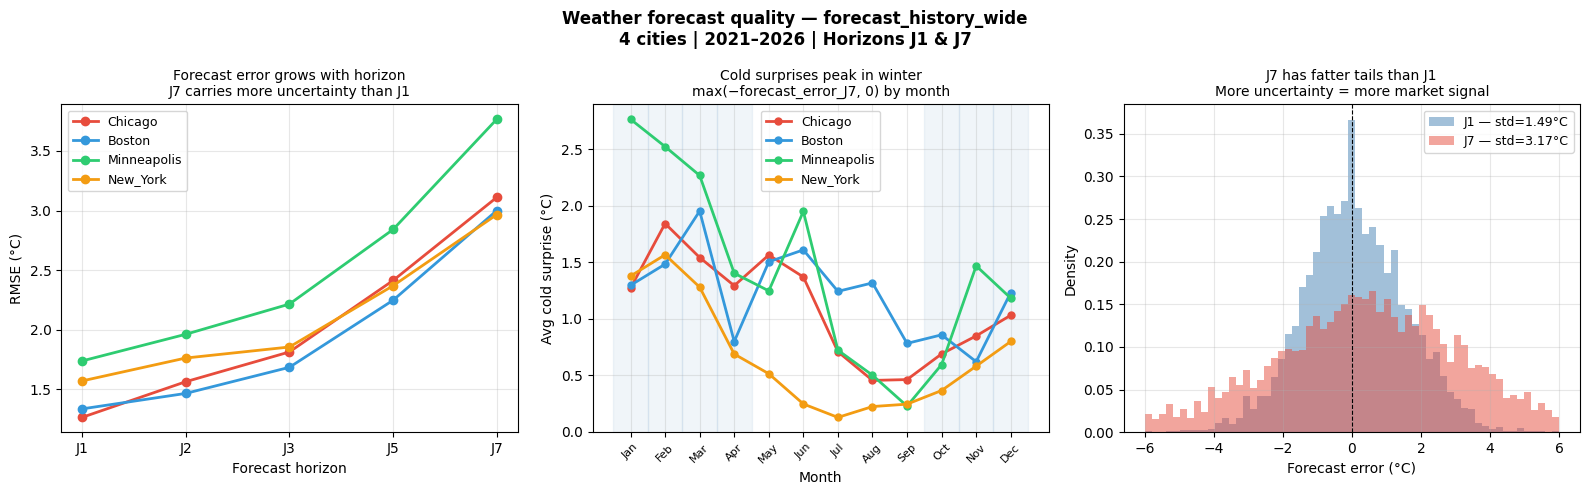

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cities = ['Chicago', 'Boston', 'Minneapolis', 'New_York']
horizons = ['J1', 'J2', 'J3', 'J5', 'J7']
colors_city = {
    'Chicago'    : '#e74c3c',
    'Boston'     : '#3498db',
    'Minneapolis': '#2ecc71',
    'New_York'   : '#f39c12',
}

# ─────────────────────────────────────────────────────────────
# Panel 1 : RMSE by horizon, shows that J7 > J1
# uncertainty grows with the horizon, non-trivial signal
# ─────────────────────────────────────────────────────────────
ax = axes[0]
for city in cities:
    df_c = df_wide[df_wide['city'] == city]
    rmse_vals = []
    for h in horizons:
        s = df_c[f'forecast_error_{h}'].dropna()
        rmse_vals.append(np.sqrt((s**2).mean()))
    ax.plot(horizons, rmse_vals, 'o-',
            color=colors_city[city], lw=2, ms=6,
            label=city)

ax.set_xlabel('Forecast horizon', fontsize=10)
ax.set_ylabel('RMSE (°C)', fontsize=10)
ax.set_title('Forecast error grows with horizon\n'
             'J7 carries more uncertainty than J1',
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# Panel 2 : cold surprise by month
# shows the surprise is concentrated in winter
# relevant signal for gas pricing
# ─────────────────────────────────────────────────────────────
ax = axes[1]
df_wide['month'] = pd.to_datetime(df_wide['date']).dt.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

for city in cities:
    df_c = df_wide[df_wide['city'] == city]
    cold = (df_c.groupby('month')['forecast_error_J7']
            .apply(lambda x: (-x.clip(upper=0)).mean()))
    ax.plot(range(1, 13), cold.values,
            'o-', color=colors_city[city],
            lw=2, ms=5, label=city)

# Winter bands
for m in [10, 11, 12, 1, 2, 3, 4]:
    ax.axvspan(m - 0.5, m + 0.5,
               alpha=0.08, color='steelblue')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Avg cold surprise (°C)', fontsize=10)
ax.set_title('Cold surprises peak in winter\n'
             'max(−forecast_error_J7, 0) by month',
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# Panel 3 : J1 vs J7 distribution (all cities pooled)
# shows that J7 has fatter tails, more signal
# ─────────────────────────────────────────────────────────────
ax = axes[2]

err_J1 = df_wide['forecast_error_J1'].dropna()
err_J7 = df_wide['forecast_error_J7'].dropna()

bins = np.linspace(-6, 6, 60)
ax.hist(err_J1, bins=bins, alpha=0.5,
        color='steelblue', density=True,
        label=f'J1 - std={err_J1.std():.2f}°C')
ax.hist(err_J7, bins=bins, alpha=0.5,
        color='#e74c3c', density=True,
        label=f'J7 - std={err_J7.std():.2f}°C')

ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Forecast error (°C)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('J7 has fatter tails than J1\n'
             'More uncertainty = more market signal',
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle(
    'Weather forecast quality - forecast_history_wide\n'
    '4 cities | 2021 to 2026 | Horizons J1 & J7',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

**Accuracy by city** Minneapolis has the highest RMSE across all horizons (consistent with its continental geographic position). Conversely, New York and Boston, benefiting from a moderating maritime influence, are the best-predicted cities.

**Degradation with horizon** The RMSE grows almost linearly from J+1 to J+7 for all cities. Each additional day of horizon introduces extra uncertainty about the future atmospheric state.

**Fat tails at J+7** The distribution of J+7 forecast errors has significantly fatter tails than at J+1 ($\sigma_{J7} = 3.17\text{°C}$ vs $\sigma_{J1} = 1.49\text{°C}$). These 2 variables also carry 2 different meanings in the interpretation we give:

- **J+1 (short-term realization surprise)** In the morning, market operators discover that the realized temperature deviates from the previous day's forecast. This gap, unanticipated by definition, generates an immediate reaction on the spot price to reflect actual heating demand.

- **J+7 (long-term expectation revision)** The GFS (Global Forecast System) models publish four daily updates (0h, 6h, 12h, 18h UTC). When the morning update significantly revises the cold forecasts for the week ahead, traders adjust their positions *before* the cold arrives. This revision is the most actionable signal on the gas market: the greater uncertainty at J+7 ($\sigma = 3.17\text{°C}$) translates into richer information content.

The question now is: which form of `weather surprise` do we use? Should we account only for cold surprises with a parameter `max(unexpected cold, 0)`, or a more general surprise effect, whether it goes one way (unexpected cold) or both ways (unexpected warmth and cold)?

Three definitions of the weather-surprise variable are tested:

* **The cold surprise (E1):** $\max(-\Delta\text{fc}, 0)$
* **The absolute value (E2):** $|\Delta\text{fc}|$
* **The raw signed surprise (E3):** $-\Delta\text{fc}$

We aggregate the weather surprises the same way as the weather anomalies, with the weights found earlier.

We test these 3 definitions in the coupling model E:
$$\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2 + \gamma_{\text{early}}\widetilde{\text{HDD}}_t^{\text{early}} + \gamma_{\text{late}}\widetilde{\text{HDD}}_t^{\text{late}} + \phi \cdot \text{WeatherSurprise}_\text{Agg}$$

In [128]:
# ─────────────────────────────────────────────────────────────
# Rebuilding df_model_E
# ─────────────────────────────────────────────────────────────

# gas consumption weights per city
weights = {
    'Chicago'    : 0.3882,
    'New_York'   : 0.3808,
    'Boston'     : 0.1109,
    'Minneapolis': 0.1201,
}

# Daily returns
r = df_main['log_ret'] * 100

# HDD anomaly
hdd       = df_main['HDD_anom_weighted'].clip(lower=0)
hdd_early = (hdd * df_main.index.month.isin([11, 12])
             .astype(float))
hdd_late  = (hdd * df_main.index.month.isin([1, 2, 3])
             .astype(float))
hdd_early.name = 'hdd_early'
hdd_late.name  = 'hdd_late'

# daily inv_tilde
inv_tilde_daily = (df_inv[['inv_tilde']]
                   .resample('D').ffill()
                   .reindex(df_main.index)
                   .ffill())

# J1 and J7 surprises
df_fc_wide['weight'] = df_fc_wide['city'].map(weights)
df_fc_wide['date']   = pd.to_datetime(df_fc_wide['date'])

surprise_J1 = (df_fc_wide
    .assign(s=lambda x:
            (-x['forecast_error_J1']).clip(lower=0) * x['weight'])
    .groupby('date')['s'].sum()
    .rename('surprise_J1'))

surprise_J7 = (df_fc_wide
    .assign(s=lambda x:
            (-x['forecast_error_J7']).clip(lower=0) * x['weight'])
    .groupby('date')['s'].sum()
    .rename('surprise_J7'))

surprise_J1.index = pd.to_datetime(surprise_J1.index)
surprise_J7.index = pd.to_datetime(surprise_J7.index)

# Winsorize
q01 = r.quantile(0.01)
q99 = r.quantile(0.99)
r_wins = r.clip(lower=q01, upper=q99)

# Assemble
df_model_E = pd.concat([
    r_wins.rename('r'),
    hdd.rename('hdd'),
    hdd_early,
    hdd_late,
    inv_tilde_daily['inv_tilde'],
    surprise_J1,
    surprise_J7,
], axis=1)

df_model_E['surprise_J1'] = df_model_E['surprise_J1'].fillna(0)
df_model_E['surprise_J7'] = df_model_E['surprise_J7'].fillna(0)
df_model_E = df_model_E.dropna(subset=['r', 'hdd'])

print(f"df_model_E : {df_model_E.shape}")
print(f"Period     : {df_model_E.index.min().date()} to "
      f"{df_model_E.index.max().date()}")
print(f"surprise_J1 non-zero : {(df_model_E['surprise_J1'] > 0).sum()}")
print(f"surprise_J7 non-zero : {(df_model_E['surprise_J7'] > 0).sum()}")

df_model_E : (7318, 7)
Période    : 1997-02-06 → 2026-04-01
surprise_J1 non-nuls : 969
surprise_J7 non-nuls : 796


In [129]:
# ─────────────────────────────────────────────────────────────
# Test : which definition of surprise_J7 is best ?
# ─────────────────────────────────────────────────────────────

df_fc_wide['weight'] = df_fc_wide['city'].map(weights)

# Version 1 : cold surprise only max(-error, 0)
surprise_cold = (df_fc_wide
    .assign(s=lambda x: 
            (-x['forecast_error_J7']).clip(lower=0) * x['weight'])
    .groupby('date')['s'].sum()
    .rename('surprise_cold'))

# Version 2 : absolute value |error|
surprise_abs = (df_fc_wide
    .assign(s=lambda x: 
            x['forecast_error_J7'].abs() * x['weight'])
    .groupby('date')['s'].sum()
    .rename('surprise_abs'))

# Version 3 : raw signed -error
# (negative = colder than forecast = upward pressure on price)
surprise_raw = (df_fc_wide
    .assign(s=lambda x: 
            (-x['forecast_error_J7']) * x['weight'])
    .groupby('date')['s'].sum()
    .rename('surprise_raw'))

# Convert the indices to datetime
for s in [surprise_cold, surprise_abs, surprise_raw]:
    s.index = pd.to_datetime(s.index)

print("=== Statistics of the three definitions ===\n")
for name, s in [('Cold max(-e,0)', surprise_cold),
                ('Abs  |e|',       surprise_abs),
                ('Raw  -e',        surprise_raw)]:
    print(f"{name:20} | mean={s.mean():.3f} | "
          f"std={s.std():.3f} | "
          f"non-nuls={( s != 0).sum()}")

# ─────────────────────────────────────────────────────────────
# Assemble df_train_E for each version
# ─────────────────────────────────────────────────────────────
df_model_test = df_model_E.copy()

for name, s in [('surprise_cold', surprise_cold),
                ('surprise_abs',  surprise_abs),
                ('surprise_raw',  surprise_raw)]:
    df_model_test[name] = s.reindex(
        df_model_test.index).fillna(0)

df_train_test = df_model_test.loc['1997':'2024'].dropna(
    subset=['r', 'hdd'])

print(f"\nTrain : {len(df_train_test)} obs")
for name in ['surprise_cold', 'surprise_abs', 'surprise_raw']:
    print(f"  {name} non-nuls : "
          f"{(df_train_test[name] > 0).sum() if name != 'surprise_raw' else (df_train_test[name] != 0).sum()}")

# ─────────────────────────────────────────────────────────────
# Normalize and estimate the 3 variants
# ─────────────────────────────────────────────────────────────
std_early = (df_train_test['hdd_early']
             [df_train_test['hdd_early'] > 0].std())
std_late  = (df_train_test['hdd_late']
             [df_train_test['hdd_late'] > 0].std())

early_n = (df_train_test['hdd_early'] / std_early
           ).rename('hdd_early')
late_n  = (df_train_test['hdd_late']  / std_late
           ).rename('hdd_late')

r_test  = df_train_test['r']

results_surprise = {}
for name in ['surprise_cold', 'surprise_abs', 'surprise_raw']:
    s      = df_train_test[name]
    # For raw : std over non-zero absolute values
    s_nonzero = s[s != 0]
    std_s  = s_nonzero.abs().std() if len(s_nonzero) > 0 else 1.0
    s_norm = (s / std_s).rename(name)

    res = fit_garch_x(
        r_test,
        exog_vars=[early_n, late_n, s_norm],
        label=f'Model E2 - surprise = {name}'
    )
    results_surprise[name] = res

# ─────────────────────────────────────────────────────────────
# Comparison table
# ─────────────────────────────────────────────────────────────
print("\n=== COMPARISON TABLE - Definition of surprise_J7 ===\n")
print(f"{'Definition':<20} {'phi':>8} {'p-val':>8} "
      f"{'AIC':>10} {'BIC':>10} {'Log-lik':>10}")
print("-"*60)

for name, res in results_surprise.items():
    p  = res['params']['coef']
    pv = res['params']['p-value']
    print(f"{name:<20} "
          f"{p[name]:>8.4f} "
          f"{pv[name]:>8.3f} "
          f"{res['aic']:>10.1f} "
          f"{res['bic']:>10.1f} "
          f"{res['loglik']:>10.1f}")

# Best specification
best = min(results_surprise.items(),
           key=lambda x: x[1]['aic'])
print(f"\n-> Best specification (AIC) : {best[0]}")

=== Statistiques des trois définitions ===

Cold max(-e,0)       | mean=0.675 | std=0.979 | non-nuls=1198
Abs  |e|             | mean=1.762 | std=1.198 | non-nuls=1792
Raw  -e              | mean=-0.413 | std=1.754 | non-nuls=1792

Train : 7009 obs
  surprise_cold non-nuls : 659
  surprise_abs non-nuls : 883
  surprise_raw non-nuls : 883

  Modèle E2 — surprise = surprise_cold
                 coef  std err    t-stat  p-value
omega          0.2703   0.0400    6.7644   0.0000
alpha          0.1149   0.0075   15.2939   0.0000
beta           0.8675   0.0083  104.1515   0.0000
hdd_early      0.4252   0.1243    3.4213   0.0006
hdd_late       0.0357   0.0676    0.5284   0.5972
surprise_cold  0.7843   0.2687    2.9188   0.0035

  Log-lik : -19073.64 | AIC : 38159.28 | BIC : 38200.41
  α + β   : 0.9824
  Convergence : Optimization terminated successfully

  Modèle E2 — surprise = surprise_abs
                coef  std err   t-stat  p-value
omega         0.2896   0.0418   6.9259   0.0000
alpha 

The raw signed surprise is **not significant** ($p=1.000$). Warm and cold surprises cancel out, confirming that it is the amplitude and not the direction of the shock that matters for conditional variance.

The absolute value $|\Delta\text{forecast}_{t,J7}|$ produces the best AIC (38149 vs 38161 for the cold surprise) with $\hat{\phi} = 0.432$ ($p<0.001$). Whatever the direction of the unexpected weather revision (whether colder or warmer than forecast), it generates uncertainty and therefore volatility. A warm surprise in January triggers unwinding of long positions and hedging adjustments that move the price in both directions.

We keep **model E2**:

$$\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2 + \gamma_{\text{early}}\widetilde{\text{HDD}}_t^{\text{early}} + \gamma_{\text{late}}\widetilde{\text{HDD}}_t^{\text{late}} + \phi \cdot |\Delta \text{forecast}_t|$$

The question now is which horizon to use. Let us test several horizons: J+1, J+7 and the two together.

In [130]:
# ─────────────────────────────────────────────────────────────
# Build surprise_abs for J1 and J7
# ─────────────────────────────────────────────────────────────

surprise_abs_J1 = (df_fc_wide
    .assign(s=lambda x: x['forecast_error_J1'].abs() * x['weight'])
    .groupby('date')['s'].sum()
    .rename('surprise_abs_J1'))

surprise_abs_J7 = (df_fc_wide
    .assign(s=lambda x: x['forecast_error_J7'].abs() * x['weight'])
    .groupby('date')['s'].sum()
    .rename('surprise_abs_J7'))

surprise_abs_J1.index = pd.to_datetime(surprise_abs_J1.index)
surprise_abs_J7.index = pd.to_datetime(surprise_abs_J7.index)

# Add to df_model_E
df_model_E['surprise_abs_J1'] = (surprise_abs_J1
    .reindex(df_model_E.index).fillna(0))
df_model_E['surprise_abs_J7'] = (surprise_abs_J7
    .reindex(df_model_E.index).fillna(0))

df_train_E = df_model_E.loc['1997':'2024'].dropna(
    subset=['r', 'hdd'])

print(f"Train : {len(df_train_E)} obs")
print(f"surprise_abs_J1 non-zero : "
      f"{(df_train_E['surprise_abs_J1'] > 0).sum()}")
print(f"surprise_abs_J7 non-zero : "
      f"{(df_train_E['surprise_abs_J7'] > 0).sum()}")

# ─────────────────────────────────────────────────────────────
# Common normalization
# ─────────────────────────────────────────────────────────────
std_early = (df_train_E['hdd_early']
             [df_train_E['hdd_early'] > 0].std())
std_late  = (df_train_E['hdd_late']
             [df_train_E['hdd_late'] > 0].std())
std_J1    = (df_train_E['surprise_abs_J1']
             [df_train_E['surprise_abs_J1'] > 0].std())
std_J7    = (df_train_E['surprise_abs_J7']
             [df_train_E['surprise_abs_J7'] > 0].std())

early_n = (df_train_E['hdd_early'] / std_early).rename('hdd_early')
late_n  = (df_train_E['hdd_late']  / std_late ).rename('hdd_late')
J1_n    = (df_train_E['surprise_abs_J1'] / std_J1).rename('surprise_J1')
J7_n    = (df_train_E['surprise_abs_J7'] / std_J7).rename('surprise_J7')

r_E = df_train_E['r']

# ─────────────────────────────────────────────────────────────
# Estimation : J1 only, J7 only, J1+J7
# ─────────────────────────────────────────────────────────────

res_E_J1 = fit_garch_x(
    r_E,
    exog_vars=[early_n, late_n, J1_n],
    label='Model E - early/late + |surprise J1|'
)

res_E_J7 = fit_garch_x(
    r_E,
    exog_vars=[early_n, late_n, J7_n],
    label='Model E - early/late + |surprise J7|'
)

res_E_both = fit_garch_x(
    r_E,
    exog_vars=[early_n, late_n, J1_n, J7_n],
    label='Model E - early/late + |J1| + |J7|'
)

# ─────────────────────────────────────────────────────────────
# Comparison table
# ─────────────────────────────────────────────────────────────
print("\n=== COMPARISON TABLE - J1 / J7 / J1+J7 ===\n")
print(f"{'Model':<30} {'g_early':>8} {'g_late':>8} "
      f"{'φ_J1':>8} {'φ_J7':>8} "
      f"{'AIC':>10} {'BIC':>10}")
print("-"*80)

for name, res in [
    ('D - early/late (ref)',      None),
    ('E - early/late + |J1|',    res_E_J1),
    ('E - early/late + |J7|',    res_E_J7),
    ('E - early/late + |J1|+|J7|', res_E_both),
]:
    if res is None:
        # Re-estimate D on the same train set for comparison
        res_D_ref = fit_garch_x(
            r_E,
            exog_vars=[early_n, late_n],
            label=''
        )
        p  = res_D_ref['params']['coef']
        pv = res_D_ref['params']['p-value']
        print(f"{'D - early/late (ref)':<30} "
              f"{p['hdd_early']:>8.4f} "
              f"{p['hdd_late']:>8.4f} "
              f"{'-':>8} {'-':>8} "
              f"{res_D_ref['aic']:>10.1f} "
              f"{res_D_ref['bic']:>10.1f}")
        continue

    p  = res['params']['coef']
    pv = res['params']['p-value']

    phi_J1 = (f"{p.get('surprise_J1', float('nan')):.4f} "
              f"({pv.get('surprise_J1', float('nan')):.3f})"
              if 'surprise_J1' in p.index else '-')
    phi_J7 = (f"{p.get('surprise_J7', float('nan')):.4f} "
              f"({pv.get('surprise_J7', float('nan')):.3f})"
              if 'surprise_J7' in p.index else '-')

    print(f"{name:<30} "
          f"{p['hdd_early']:>8.4f} "
          f"{p['hdd_late']:>8.4f} "
          f"{phi_J1:>18} "
          f"{phi_J7:>18} "
          f"{res['aic']:>10.1f} "
          f"{res['bic']:>10.1f}")

# Best model
best = min(
    [('E_J1', res_E_J1), ('E_J7', res_E_J7),
     ('E_both', res_E_both)],
    key=lambda x: x[1]['aic']
)
print(f"\n-> Best specification (AIC) : {best[0]}")

Train : 7009 obs
surprise_abs_J1 non-nuls : 887
surprise_abs_J7 non-nuls : 883

  Modèle E — early/late + |surprise J1|
               coef  std err    t-stat  p-value
omega        0.2852   0.0414    6.8871   0.0000
alpha        0.1146   0.0075   15.2007   0.0000
beta         0.8648   0.0086  100.8248   0.0000
hdd_early    0.4523   0.1282    3.5274   0.0004
hdd_late     0.0540   0.0700    0.7721   0.4401
surprise_J1  0.4095   0.1061    3.8590   0.0001

  Log-lik : -19067.79 | AIC : 38147.58 | BIC : 38188.71
  α + β   : 0.9794
  Convergence : Optimization terminated successfully

  Modèle E — early/late + |surprise J7|
               coef  std err   t-stat  p-value
omega        0.2896   0.0418   6.9259   0.0000
alpha        0.1148   0.0076  15.1671   0.0000
beta         0.8640   0.0086  99.9436   0.0000
hdd_early    0.4572   0.1290   3.5431   0.0004
hdd_late     0.0557   0.0703   0.7923   0.4282
surprise_J7  0.4977   0.1234   4.0317   0.0001

  Log-lik : -19066.60 | AIC : 38145.21 | BIC

We notice that the 2 variables together are significant. Yet the GARCH that couples them cancels out the effect of the J+1 forecast entirely. The 7-day expectation revision already contains the information of the 1-day surprise and more. The market looks mainly at J7 to position itself. J1 adds nothing marginal once J7 is included. We can also see that the 2 variables are strongly correlated.

In [134]:
# Correlation between surprise_abs_J1 and surprise_abs_J7
corr = df_model_E['surprise_abs_J1'].corr(
       df_model_E['surprise_abs_J7'])

# On the days where both are non-zero
mask = (df_model_E['surprise_abs_J1'] > 0) & \
       (df_model_E['surprise_abs_J7'] > 0)
corr_active = df_model_E.loc[mask, 'surprise_abs_J1'].corr(
              df_model_E.loc[mask, 'surprise_abs_J7'])

print(f"Global corr   (J1, J7) : {corr:.4f}")
print(f"Corr active   (J1, J7) : {corr_active:.4f}")
print(f"Active observations    : {mask.sum()}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Corr globale  (J1, J7) : 0.7780
Corr active   (J1, J7) : 0.3503
Observations actives   : 1184


**Model E** integrates this variable into the variance equation:

$$\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2 + \gamma_{\text{early}}\widetilde{\text{HDD}}_t^{\text{early}} + \gamma_{\text{late}}\widetilde{\text{HDD}}_t^{\text{late}} + \phi \cdot \text{surprise}_t$$

where $\text{surprise}_t = \max(0, T_t - T_{t-1}^{\text{prev}})$ measures the gap between realized temperature and the day-ahead forecast.

In [135]:
# Compare the distributions
print("=== Surprise J+1 ===")
print((-df_fc_wide['forecast_error_J1']).clip(lower=0).describe().round(3))

print("\n=== Revision J+7 ===")
df_fc_wide_sorted = (df_fc_wide
    .sort_values(['city', 'date'])
    .copy())
df_fc_wide_sorted['revision_J7'] = (
    df_fc_wide_sorted
    .groupby('city')['dat_f_J7']
    .diff()
)
print((-df_fc_wide_sorted['revision_J7']).clip(lower=0).describe().round(3))

=== Surprise J+1 ===
count    4783.000
mean        0.543
std         0.831
min         0.000
25%         0.000
50%         0.000
75%         0.900
max         6.550
Name: forecast_error_J1, dtype: float64

=== Révision J+7 ===
count    4765.000
mean        1.232
std         1.929
min         0.000
25%         0.000
50%         0.000
75%         1.900
max        11.750
Name: revision_J7, dtype: float64


Thus, at the end of this (long...) analysis, we will conclude on the Baseline, B, D and E2 models. We keep model D without the forecast because of notorious data limitations on model E2...

In [136]:
# Remove holidays
df_full_clean = df_full[df_full['r'] != 0].copy()

print(f"Before : {len(df_full)} obs")
print(f"After : {len(df_full_clean)} obs")
print(f"Removed : {len(df_full) - len(df_full_clean)} holidays")

# Check the gaps
gaps = df_full_clean.index.to_series().diff().dt.days
print(f"Gaps > 3 days : {(gaps > 3).sum()}")
print(gaps[gaps > 3].value_counts().head())

NameError: name 'df_full' is not defined

In [ ]:
# Re-run the backtest on df_full_clean
print("\nBacktest expanding window - annual refit\n")

bt_A,  _, _ = backtest_expanding(
    df_full_clean, exog_cols=[],
    label='A - Baseline')

bt_B,  _, _ = backtest_expanding(
    df_full_clean, exog_cols=['hdd'],
    label='B - HDD')

bt_D,  _, _ = backtest_expanding(
    df_full_clean, exog_cols=['hdd_early', 'hdd_late'],
    label='D - early/late')

bt_E2, _, _ = backtest_expanding(
    df_full_clean,
    exog_cols=['hdd_early', 'hdd_late', 'surprise_abs_J7'],
    label='E2 - early/late + |J7|')

# Recompute QLIKE
qlike_daily_all = {}
for name, bt in [('A - Baseline',       bt_A),
                 ('B - HDD',            bt_B),
                 ('D - early/late',     bt_D),
                 ('E2 - early/late+J7', bt_E2)]:

    bt = bt[~bt.index.duplicated(keep='last')]
    sigma2 = bt['sigma_pred'] ** 2
    r2     = bt['abs_r'] ** 2

    df_q   = pd.concat([sigma2, r2], axis=1).dropna()
    df_q.columns = ['pred', 'actual']
    df_q   = df_q[df_q['actual'] > 0]  # exclude r=0

    qlike_daily_all[name] = (
        df_q['actual'] / df_q['pred']
        - np.log(df_q['actual'] / df_q['pred'])
        - 1
    )

# Final QLIKE table
qlike_results = {}
print("\n=== FINAL QLIKE ===\n")
print(f"{'Model':<25} {'Global':>10} {'Winter':>10} "
      f"{'Surprise>0':>12}")
print("-"*60)

winter_months = [10, 11, 12, 1, 2, 3, 4]

for name, ql in qlike_daily_all.items():
    bt = [bt_A, bt_B, bt_D, bt_E2][
        ['A - Baseline', 'B - HDD',
         'D - early/late', 'E2 - early/late+J7'].index(name)
    ]
    bt = bt[~bt.index.duplicated(keep='last')]

    ql_g = ql.mean()
    ql_w = ql[ql.index.month.isin(winter_months)].mean()

    surp  = df_full_clean.loc[ql.index,
                               'surprise_abs_J7'] > 0
    ql_s  = ql[surp].mean()

    qlike_results[name] = {
        'global'  : ql_g,
        'winter'  : ql_w,
        'surprise': ql_s,
        'bt'      : bt,
        'sigma2'  : bt['sigma_pred'] ** 2,
    }

    print(f"{name:<25} {ql_g:>10.6f} "
          f"{ql_w:>10.6f} {ql_s:>12.6f}")

print(f"\n-> Best global   : "
      f"{min(qlike_results, key=lambda x: qlike_results[x]['global'])}")
print(f"-> Best winter    : "
      f"{min(qlike_results, key=lambda x: qlike_results[x]['winter'])}")
print(f"-> Best surprise : "
      f"{min(qlike_results, key=lambda x: qlike_results[x]['surprise'])}")


Backtest expanding window — refit annuel

  Refit 2015-01-01 — 4213 obs ... ✓ loglik=-11277.9
  Refit 2016-01-01 — 4393 obs ... ✓ loglik=-11763.7
  Refit 2017-01-01 — 4593 obs ... ✓ loglik=-12334.3
  Refit 2018-01-01 — 4795 obs ... ✓ loglik=-12863.2
  Refit 2019-01-01 — 4995 obs ... ✓ loglik=-13371.4
  Refit 2020-01-01 — 5206 obs ... ✓ loglik=-13971.8
  Refit 2021-01-01 — 5446 obs ... ✓ loglik=-14731.7
  Refit 2022-01-01 — 5685 obs ... ✓ loglik=-15398.9
  Refit 2023-01-01 — 5928 obs ... ✓ loglik=-16199.5
  Refit 2024-01-01 — 6161 obs ... ✓ loglik=-16938.8
  Refit 2025-01-01 — 6397 obs ... ✓ loglik=-17749.8
  Refit 2026-01-01 — 6631 obs ... ✓ loglik=-18491.5

  A — Baseline
  RMSE : 3.5373 | MAE : 2.8211 | N : 2476

  Refit 2015-01-01 — 4213 obs ... ✓ loglik=-11277.4
  Refit 2016-01-01 — 4393 obs ... ✓ loglik=-11763.1
  Refit 2017-01-01 — 4593 obs ... ✓ loglik=-12333.7
  Refit 2018-01-01 — 4795 obs ... ✓ loglik=-12861.6
  Refit 2019-01-01 — 4995 obs ... ✓ loglik=-13369.6
  Refit 2020-0

In [ ]:
# ─────────────────────────────────────────────────────────────
# Plotly plot - corrected version
# ─────────────────────────────────────────────────────────────

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        'Cumulative QLIKE differential vs Baseline A - < 0 = better than A',
        'Smoothed ΔQLIKE (21d) vs Baseline A - < 0 = better than A',
        'Predicted σ (annualized) vs |r_t| - model comparison',
    ],
    vertical_spacing=0.09,
    row_heights=[0.28, 0.28, 0.44]
)

# Winter bands
for year in range(2015, 2027):
    for xref in ['x', 'x2', 'x3']:
        fig.add_shape(
            type='rect',
            xref=xref, yref='paper',
            x0=f'{year}-10-01',
            x1=f'{year+1}-04-30',
            fillcolor='steelblue',
            opacity=0.06,
            line_width=0,
            layer='below'
        )

qlike_A = qlike_daily_all['A - Baseline']

# ─────────────────────────────────────────────────────────────
# Panel 1 : cumulative QLIKE differential vs A
# ─────────────────────────────────────────────────────────────
for name, ql in qlike_daily_all.items():
    if name == 'A - Baseline':
        continue
    common   = ql.index.intersection(qlike_A.index)
    diff_cum = (ql.loc[common] -
                qlike_A.loc[common]).cumsum()

    fig.add_trace(go.Scatter(
        x=diff_cum.index, y=diff_cum,
        name=name,
        line=dict(color=colors[name], width=1.5),
        legendgroup=name,
    ), row=1, col=1)

fig.add_hline(y=0, line_dash='dash',
              line_color='black', line_width=0.8,
              row=1, col=1)

# ─────────────────────────────────────────────────────────────
# Panel 2 : smoothed 21d QLIKE differential vs A
# ─────────────────────────────────────────────────────────────
for name, ql in qlike_daily_all.items():
    if name == 'A - Baseline':
        continue
    common      = ql.index.intersection(qlike_A.index)
    diff_smooth = (ql.loc[common] -
                   qlike_A.loc[common]).rolling(
                   21, center=True).mean()

    fig.add_trace(go.Scatter(
        x=diff_smooth.index, y=diff_smooth,
        name=name,
        line=dict(color=colors[name], width=1.2),
        legendgroup=name,
        showlegend=False,
    ), row=2, col=1)

fig.add_hline(y=0, line_dash='dash',
              line_color='black', line_width=0.8,
              row=2, col=1)

# ─────────────────────────────────────────────────────────────
# Panel 3 : annualized sigma_pred vs |r_t|
# ─────────────────────────────────────────────────────────────

# |r_t| annualized, without the zeros
abs_r_ann = (df_full_clean['r'].abs() * np.sqrt(252))
abs_r_ann = abs_r_ann[~abs_r_ann.index.duplicated(keep='last')]
abs_r_ann = abs_r_ann.clip(upper=abs_r_ann.quantile(0.99))

fig.add_trace(go.Scatter(
    x=abs_r_ann.index,
    y=abs_r_ann,
    name='|r_t| annualized',
    line=dict(color='black', width=0.5),
    opacity=0.35,
    legendgroup='realized',
), row=3, col=1)

for name, res in qlike_results.items():
    bt        = res['bt'][
        ~res['bt'].index.duplicated(keep='last')]
    sigma_ann = bt['sigma_pred'] * np.sqrt(252)

    fig.add_trace(go.Scatter(
        x=sigma_ann.index,
        y=sigma_ann,
        name=f'σ {name}',
        line=dict(color=colors[name], width=0.9),
        opacity=0.85,
        legendgroup=True,
        showlegend=False,
    ), row=3, col=1)

# J7 surprise days on E2
surp_mask  = df_full_clean['surprise_abs_J7'] > 0
surp_dates = df_full_clean[surp_mask].index
bt_E2_c    = qlike_results['E2 - early/late+J7']['bt']
bt_E2_c    = bt_E2_c[~bt_E2_c.index.duplicated(keep='last')]
surp_dates = surp_dates[surp_dates.isin(bt_E2_c.index)]

fig.add_trace(go.Scatter(
    x=surp_dates,
    y=bt_E2_c.loc[surp_dates, 'sigma_pred'] * np.sqrt(252),
    mode='markers',
    name='J7 surprise > 0',
    marker=dict(color='gold', size=4,
                opacity=0.7, symbol='circle'),
    legendgroup='surprise',
), row=3, col=1)

# ─────────────────────────────────────────────────────────────
# Layout
# ─────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='Backtest QLIKE - Expanding window (annual refit)<br>'
             '<sup>Models A / B / D / E2 | '
             'Blue zones = winters Oct-Apr | '
             'Gold = J7 surprise days</sup>',
        font=dict(size=14)
    ),
    height=1000,
    hovermode='x unified',
    template='plotly_white',
    legend=dict(
        orientation='h',
        yanchor='bottom', y=1.02,
        xanchor='right', x=1,
        font=dict(size=10)
    ),
)

fig.update_yaxes(title_text='Cumul. QLIKE diff.',
                 row=1, col=1)
fig.update_yaxes(title_text='ΔQLIKE smoothed 21d',
                 row=2, col=1)
fig.update_yaxes(title_text='Annualized vol (%)',
                 row=3, col=1)

# Range slider on panel 1
fig.update_xaxes(
    rangeslider=dict(visible=True, thickness=0.03),
    row=1, col=1
)
# Zoom on 2015+ for panels 2 and 3
for row in [2, 3]:
    fig.update_xaxes(
        range=['2015-01-01',
               df_full_clean.index.max()
               .strftime('%Y-%m-%d')],
        row=row, col=1
    )

fig.show()